# 5 · Courbes et surfaces — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch05_courbes/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 5.1 à 5.5 | vérifier tes exercices papier ✏️ | ✏️ | ★ à ★★ | |
| A | 5.11 | Dérivées numériques : première et seconde | 🔨 | ★★ | 25 |
|  | 5.12 | Quel pas h choisir ? Prédire la courbe d'erreur | 🔮 | ★★ | 15 |
|  | 5.13 | Erreur de troncature contre erreur d'arrondi | 🔬 | ★★ | 25 |
|  | 5.14 | Les maxima des cycles solaires | 🔨 | ★★ | 30 |
| B | 5.15 | numerical_gradient sur la vallée de Rosenbrock | 🔨 | ★★ | 25 |
|  | 5.16 | Le gradient qui abîme son entrée | 🐛 | ★★ | 20 |
|  | 5.17 | Lire des lignes de niveau : où pointe le gradient ? | 📈 | ★★ | 20 |
| C | 5.18 | gradient_descent, et sa version qui monte | 🔨 | ★★ | 30 |
|  | 5.19 | Learning rate sur un bol : trop petit, juste, trop grand | 🔬 | ★★ | 25 |
|  | 5.20 | Démarrer pile sur un point selle | 🔮 | ★★ | 15 |
|  | 5.21 | Le même gradient avec torch.autograd | 📦 | ★★ | 20 |
| D | 5.22 | L'eau qui descend la surface (figure 5.18) | 🎨 | ★★ | 30 |
|  | 5.23 | Tests de propriétés paramétrés avec pytest | 🛠️ | ★★ | 20 |
|  | 5.24 | Minimum, maximum, selle ou plat : classify_critical_point | 🔨 | ★★★ | 35 |
|  | 5.25 | Atteindre le fond de la vallée de Rosenbrock | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        conflicts = subprocess.run(["git", "-C", str(DRIVE_DIR), "diff", "--name-only", "--diff-filter=U"],
                                   capture_output=True, text=True).stdout.split()
        if conflicts:  # a file changed outside mon_travail/ AND by Claude: git leaves conflict markers in it
            print("⚠️ Tes modifications de " + ", ".join(conflicts) + " (hors de mon_travail/) entrent en conflit "
                  "avec la nouvelle version ; elles sont gardées dans `git stash`. Pour reprendre la version du "
                  "dépôt : git restore --source=HEAD --staged --worktree <fichier> (00_setup/COLAB.md, « Problèmes "
                  "fréquents »).")
        elif pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Estimer une dérivée et un gradient par différences finies, et choisir le pas $h$ (troncature contre arrondi).
- Repérer les extrema d'une courbe échantillonnée, et classer les points critiques d'une surface (minimum, maximum, point selle).
- Écrire et régler une descente de gradient : le learning rate, les courbures, les points selles.
- Comparer le gradient numérique et la différentiation automatique (`torch.autograd`).

**Rappel express.** Pente centrée $\frac{f(x + h) - f(x - h)}{2h}$ (erreur en $h^2$), avant $\frac{f(x + h) - f(x)}{h}$ (erreur en $h$) ; dérivée seconde $\frac{f(x + h) - 2f(x) + f(x - h)}{h^2}$ ; gradient $\nabla f = \left(\frac{\partial f}{\partial x_1}, \ldots, \frac{\partial f}{\partial x_n}\right)$, perpendiculaire aux lignes de niveau, vers la plus grande montée ; descente $\mathbf{x} \leftarrow \mathbf{x} - \eta\,\nabla f(\mathbf{x})$. En Python : `np.array(x, dtype=float)` (une copie), `np.linalg.norm`, `np.meshgrid`, `ax.contour`, `ax.quiver`, `torch.tensor(..., requires_grad=True)` et `.backward()`.

## Partie 0 · Vérifier tes exercices papier (✏️ 5.1 à 5.5)

Fais d'abord les exercices ✏️ de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse ici : **la valeur** que tu as trouvée (par exemple `42`, `0.125`, `[1, 2, 3]` ou `True`), pas l'expression Python, sinon tu ne vérifies rien. En Python, le séparateur décimal est un **point** (`0.125`) ; `0,125` sans guillemets serait un couple de deux nombres. Arrondis comme l'énoncé le demande, et seulement à la fin du calcul ; quand l'énoncé dit « valeurs exactes », donne-les sans arrondir. Les réponses pas encore remplies affichent ⏳. Les exercices ∂ 5.6 et 5.7 se corrigent avec `05_solutions.md`.

In [2]:
# The paper exercises only use the numbers of their statements (02_exercices.md)
from fractions import Fraction as Fr

import numpy as np


def inverse(x):
    """5.1: f(x) = 1/x, exact with fractions."""
    return 1 / Fr(x)


def symmetric_slope(f, a, h):
    """Slope of the secant through the points of abscissas a - h and a + h."""
    return (f(a + h) - f(a - h)) / (2 * h)


A51 = Fr(2)
SYM_51 = {h: symmetric_slope(inverse, A51, Fr(h)) for h in ("1", "1/2", "1/10")}
FORWARD_51 = (inverse(Fr("2.1")) - inverse(A51)) / Fr("0.1")
BACKWARD_51 = (inverse(A51) - inverse(Fr("1.9"))) / Fr("0.1")
DERIV_51 = Fr(-1, 4)


def grad_52(x, y):
    """5.2: gradient of x² + xy + 2y²."""
    return np.array([2 * x + y, x + 4 * y], dtype=float)


G52 = grad_52(1, -1)
NORM_52 = float(np.linalg.norm(G52))
U52 = np.array([0.6, 0.8])


def descend_53(x, eta, steps, derivative, sign=-1.0):
    """5.3: the points x_1, ..., x_steps of a descent (sign -1) or an ascent (sign +1)."""
    points = []
    for _ in range(steps):
        x = x + sign * eta * derivative(x)
        points.append(x)
    return points


def f53(x):
    return 2 * (x - 1) ** 2


def df53(x):
    return 4 * (x - 1)


def dg53(x):
    return 4 - 2 * x


def f54(x):
    return x ** 3 - 3 * x


def saddle_steps_55(point, eta, steps, flipped_y=False):
    """5.5: descent on x² - y² (gradient (2x, -2y)); flipped_y uses the wrong sign for y."""
    x, y = point
    for _ in range(steps):
        x, y = x - eta * 2 * x, y - eta * (2 * y if flipped_y else -2 * y)
    return [x, y]

**Ex 5.1 — La sécante qui se resserre sur la tangente**

In [3]:
wb.record("5.1a", float(SYM_51["1"]), decimals=3, mistakes={"c'est la sécante avant, de 2 à 3 : la sécante symétrique passe par les points d'abscisses 1 et 3": float(inverse(3) - inverse(2)),
                     "les deux points sont distants de 2h : divise la différence des hauteurs par 2h, pas par h": float(2 * SYM_51["1"])})
wb.record("5.1b", float(SYM_51["1/2"]), decimals=4, mistakes={"c'est la sécante avant, de 2 à 2,5 : la sécante symétrique passe par 1,5 et 2,5": float((inverse(Fr("2.5")) - inverse(2)) / Fr("0.5")),
                     "les deux points sont distants de 2h : divise par 2h, pas par h": float(2 * SYM_51["1/2"])})
wb.record("5.1c", float(SYM_51["1/10"]), decimals=5, mistakes={"c'est la sécante avant (question e) : la sécante symétrique passe par 1,9 et 2,1": float(FORWARD_51),
                     "les deux points sont distants de 2h : divise par 2h, pas par h": float(2 * SYM_51["1/10"])})
wb.record("5.1d", float(DERIV_51), decimals=4, mistakes={"c'est la pente pour h = 0,1 (question c) : on demande la limite quand h tend vers 0": float(SYM_51["1/10"])})
wb.record("5.1e", float(FORWARD_51), decimals=4, mistakes={"c'est la pente symétrique (question c) : on demande la sécante avant, entre 2 et 2,1": float(SYM_51["1/10"]),
                     "c'est la sécante arrière, entre 1,9 et 2 : on demande la sécante avant, entre 2 et 2,1": float(BACKWARD_51)})
wb.record("5.1f", float(abs(FORWARD_51 - DERIV_51) / abs(SYM_51['1/10'] - DERIV_51)), decimals=1, mistakes={"c'est l'inverse : mets l'écart de la pente avant au numérateur": float(abs(SYM_51["1/10"] - DERIV_51) / abs(FORWARD_51 - DERIV_51)),
                     "tu as utilisé les valeurs arrondies de c) et e) : garde les fractions exactes jusqu'au bout": (0.25 - 0.2381) / (0.25063 - 0.25)})

WB_ANSWER {"decimals": 3, "hash": "365572fcdebdb5f80fc3963fccfb549d82afae42ef97c4783572f870c225c6aa", "hash_coarse": "a86293784dfa327d127f2692d8239ec9c0be8ebd4bcd1629a1ef5876d225fe49", "id": "5.1a", "kind": "float", "magnitude": -1, "mistakes": {"0febb23e30f3493eaf3d63f1ff1edaa6a0bbbecbc7f791974ac66b4c4cbd75fd": "c'est la sécante avant, de 2 à 3 : la sécante symétrique passe par les points d'abscisses 1 et 3", "379d11c2c0d59182f959df129e803cdf17d887827aa515fce988047956426ea9": "les deux points sont distants de 2h : divise la différence des hauteurs par 2h, pas par h"}, "sign": -1}
📝 Ex 5.1a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "555915f60c1daa27147c2820ec75cf3cb29b8e899811872c831fadbadf82c7c6", "hash_coarse": "f6955ff2ac2301361e8c1fca63eeb8221db2fb30f0624cdedaa7f8af1cb9600a", "id": "5.1b", "kind": "float", "magnitude": -1, "mistakes": {"2ba2b4b65f1ebf9073fdc1f0a66c0fc7e92dc5dc0b5a7b402fcf95e4d8e28630": "c'est la sécante avant, de 2 à 2,5 : la s

**Ex 5.2 — Gradient à la main et direction de plus grande pente**

In [4]:
wb.record("5.2a", 1 ** 2 + 1 * (-1) + 2 * (-1) ** 2, mistakes={"vérifie le signe du terme xy en P, et que le carré de 2y² ne porte que sur y": 1 + 1 + 2,
           "2y² vaut 2 × (−1)² = 2 en P : n'oublie pas le facteur 2": 1 - 1 + 1})
wb.record("5.2b", G52.tolist(), mistakes={"tu as oublié le terme xy : il dépend des deux variables, il compte dans les deux dérivées partielles": [2.0, -4.0],
           "l'ordre demandé est [∂f/∂x, ∂f/∂y]": G52[::-1].tolist()})
wb.record("5.2c", NORM_52, decimals=3, mistakes={"c'est le carré de la norme : prends la racine carrée": NORM_52 ** 2,
                     "c'est la norme d'un gradient sans le terme xy": float(np.linalg.norm([2, -4]))})
wb.record("5.2d", (-G52 / NORM_52).tolist(), decimals=3, mistakes={"c'est la direction de plus grande MONTÉE : la descente va contre le gradient": (G52 / NORM_52).tolist(),
                     "un vecteur unitaire a une norme 1 : divise par la norme du gradient": (-G52).tolist()})
wb.record("5.2e", float(G52 @ U52), decimals=1, mistakes={"chaque composante du gradient se multiplie par la composante de u de même rang": float(G52[0] * U52[1] + G52[1] * U52[0]),
                     "c'est la plus grande pente (la norme du gradient) : on demande la pente dans la direction u": NORM_52})
wb.record("5.2f", (np.array([3.0, 1.0]) / np.sqrt(10)).tolist(), decimals=3, mistakes={"l'énoncé demande la direction de première composante positive": (np.array([-3.0, -1.0]) / np.sqrt(10)).tolist(),
                     "un vecteur unitaire a une norme 1 : divise par sa norme": [3.0, 1.0],
                     "vérifie que son produit scalaire avec le gradient est nul : celui-ci ne l'est pas": (np.array([1.0, 3.0]) / np.sqrt(10)).tolist()})

WB_ANSWER {"hash": "5ebc4ca765403a22dbf4d6752d097b3fd9137f4bc6e1b08262431f3fcb506e8c", "id": "5.2a", "kind": "int", "magnitude": 0, "mistakes": {"97d4f7a81da85c588b4169f23dd0a2c5f7f76bff4bc6501880a33b2c8079f504": "vérifie le signe du terme xy en P, et que le carré de 2y² ne porte que sur y", "d3fb3cda4885387aa50989a533cf1b2a368f896a464a69b24b1e4040e3a2b015": "2y² vaut 2 × (−1)² = 2 en P : n'oublie pas le facteur 2"}, "sign": 1}
📝 Ex 5.2a : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["476cab20ae546e2f317789ea8155d2afb92f44d843fa494c3fe49f128795fe2e", "7a51063eba2e8365d4464dfaa0399f7835838bac1c11d608c4ccb37de8be38e7"], "hash": "028ac2be0d923948f26b3dc944cfba0e1a16059484788c10588f29b351abef9e", "id": "5.2b", "integer": true, "kind": "array", "mistakes": {"351e1f1fc206c070bdb0a50c49aa7d3fa55155c64d5f1aacf9031a8fee92c6b0": "tu as oublié le terme xy : il dépend des deux variables, il compte dans les deux dérivées partielles", "b331408ff99683491169d3268879473d47b66

**Ex 5.3 — Trois pas de descente de gradient à la main**

In [5]:
wb.record("5.3a", df53(5), mistakes={"la dérivée de 2(x − 1)² est 4(x − 1) : n'oublie pas le facteur 2 qui est devant": 2 * (5 - 1),
           "c'est f(5) : on demande la dérivée f'(5)": f53(5)})
wb.record("5.3b", descend_53(5.0, 0.125, 3, df53), decimals=3, mistakes={"tu es monté : pour descendre, on RETIRE η f'(x)": descend_53(5.0, 0.125, 3, df53, sign=1.0),
           "la dérivée de 2(x − 1)² est 4(x − 1) : n'oublie pas le facteur 2": descend_53(5.0, 0.125, 3, lambda x: 2 * (x - 1)),
           "on demande les trois points SUIVANTS, x1, x2 et x3 : pas le point de départ x0": [5.0] + descend_53(5.0, 0.125, 2, df53),
           "x0 n'est pas à donner : la liste ne contient que x1, x2 et x3": [5.0] + descend_53(5.0, 0.125, 3, df53)})
wb.record("5.3c", [f53(x) for x in [5.0] + descend_53(5.0, 0.125, 3, df53)], decimals=3)
wb.record("5.3d", descend_53(-1.0, 0.25, 3, dg53, sign=1.0), decimals=3, mistakes={"tu es descendu : pour monter, on AJOUTE η g'(x)": descend_53(-1.0, 0.25, 3, dg53)})
wb.record("5.3e", descend_53(5.0, 0.5, 2, df53), mistakes={"c'est avec η = 0,125 : refais les deux pas avec η = 0,5": descend_53(5.0, 0.125, 2, df53)})
wb.record("5.3f", 0.5, decimals=2, mistakes={"au-delà de cette valeur, x dépasse le minimum, mais s'en rapproche encore : écris la condition |1 − 4η| < 1": 0.25})
wb.record("5.3g", 0.25, decimals=2, mistakes={"à cette valeur, la descente rebondit d'un côté à l'autre (e) : cherche le η pour lequel 1 − 4η = 0": 0.5})

WB_ANSWER {"hash": "9fee42286c44b45eabc0fe2108b1976e1e7b9c238a24ea879b48227d75d7b8c3", "id": "5.3a", "kind": "int", "magnitude": 1, "mistakes": {"19c9f120933db297c35f62a1a8e2a01c28cac1cca7ede7d3449840a13fbb5032": "la dérivée de 2(x − 1)² est 4(x − 1) : n'oublie pas le facteur 2 qui est devant", "6b63caafd41342d072db33504b6b1354d723fe027ab8d250cc278b26cf8fa650": "c'est f(5) : on demande la dérivée f'(5)"}, "sign": 1}
📝 Ex 5.3a : réponse enregistrée (int).
WB_ANSWER {"decimals": 3, "element_coarse": [["203d1d715d08bc00dc5e880a018a95a51d4f7c474a6605a63276dcd5c0b9f6c8"], ["0cd577f42a9a04c44c3e215523c6a991dcdf653b43f42183d661ac3155c81bbf"], ["eb89fbd11f5d2ae3a9a88660ba2798b6c2c195ce37985334ab4ee24369ca94d1"]], "element_hashes": ["bbe79a1c06d219404c533ea47d9007f4f7d5fbe4ad65926d291caa91b2670124", "8c7cdcedd2f35b838712b93b16996b850c16a6e02f9817472457b23329245b83", "f2515c8efa0c85afbeea338785b7eba9df38703473a4e4467250c6386c9b3654"], "hash": "dca92ab4ca0d41e4b88cd4e77450486c5d1df9e18bc909417565

**Ex 5.4 — Tableau de variations : extrema locaux et globaux de x³ − 3x**

In [6]:
wb.record("5.4a", [-1, 1], decimals=3, mistakes={"l'ordre demandé est croissant": [1, -1],
                     "ce sont les points où f s'annule : on demande ceux où sa DÉRIVÉE s'annule": [-np.sqrt(3), np.sqrt(3)],
                     "ce sont les trois points où f s'annule : on demande ceux où sa DÉRIVÉE s'annule": [-np.sqrt(3), 0, np.sqrt(3)]})
wb.record("5.4b", [f54(-1), f54(1)], mistakes={"garde l'ordre de a), croissant": [f54(1), f54(-1)]})
wb.record("5.4c", 6 * (-1), mistakes={"6, c'est la dérivée seconde au plus GRAND des deux points (ou une dérivée seconde qui a perdu son x) : on la demande au plus petit": 6,
           "c'est la dérivée PREMIÈRE, nulle en ce point critique : dérive une seconde fois": 0})
wb.record("5.4d", f54(2.5), decimals=3, mistakes={"c'est le maximum LOCAL, en −1 : sur [−2,5 ; 2,5], compare aussi les valeurs aux bornes": f54(-1)})
wb.record("5.4e", 2.5, decimals=1, mistakes={"le maximum local n'est pas le maximum global sur cet intervalle : regarde les bornes": -1,
                     "c'est l'abscisse du minimum global": -2.5})
wb.record("5.4f", 2, mistakes={"f(2) vaut aussi 2 : compte tous les points où f atteint sa valeur maximale sur [−2 ; 2]": 1})
wb.record("5.4g", 0, mistakes={"1 annule f′ (c'est un point critique) : le point d'inflexion annule f″": 1,
           "−1 annule f′ (c'est un point critique) : le point d'inflexion annule f″": -1})

WB_ANSWER {"decimals": 3, "element_coarse": [["d2ce52656fd2cbe74dfdb47c2877e37b38147cbfea2f6e0ea6b4530cf85efbcc"], ["299f8f91f639d237db4d40f58a8d1726d90887dc941835f6d7e41dee0fcfb04d"]], "element_hashes": ["f29623244980001ef1e5daa46781f8cf8619d3d41d0cb249c748c44fc56f2abf", "6bd81f5f6b8d38b2fe6789a14c4f73472c6bd9771bb42ab026d541bcca2b02a2"], "hash": "a9f843a69f28bf5d13c4405ffa827ad53fc9100aa74b142c8189955f01113baa", "id": "5.4a", "kind": "array", "mistakes": {"615dfb8b3272a248cbc67480a50bddc5020d3001557c372fc53dbd91a1e1c007": "l'ordre demandé est croissant", "ab2f0ce202aeac82f6329f2b425302dce81ddb317255998f701ff378c1c0086b": "ce sont les trois points où f s'annule : on demande ceux où sa DÉRIVÉE s'annule", "c0fef2b92de977c1c9b6fb265c01668ae03798bf132dc2d7580b4536e0b54e1d": "ce sont les points où f s'annule : on demande ceux où sa DÉRIVÉE s'annule"}, "shape": [2]}
📝 Ex 5.4a : réponse enregistrée (array, 3 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["d6453bcc5a8f4eaf18828345

**Ex 5.5 — Point selle : x² − y² vu dans deux directions**

In [7]:
wb.record("5.5a", [0, 0])
wb.record("5.5b", [2, -2], mistakes={"la dérivée seconde de t² vaut 2, pas 1": [1, -1],
           "l'ordre demandé : le long de l'axe des x d'abord": [-2, 2]})
wb.record("5.5c", 2 * np.cos(np.radians(60)), decimals=1, mistakes={"cos² θ − sin² θ ne vaut pas cos θ : cherche la bonne formule de trigonométrie (0B)": 2 * np.cos(np.radians(30)),
                     "c'est le coefficient de t² : la dérivée seconde de a t² vaut 2a": np.cos(np.radians(60)),
                     "ta dérivée seconde est nulle : refais le développement de f(t cos θ, t sin θ), il reste un terme en t²": 0.0,
                     "ta calculatrice est en radians : passe-la en degrés": 2 * np.cos(60)})
wb.record("5.5d", 45, mistakes={"ta réponse ressemble à un angle en radians : on le demande en degrés": 1})
wb.record("5.5e", saddle_steps_55((0.5, 0.1), 0.25, 2), decimals=3, mistakes={"∂f/∂y = −2y : la descente retranche η × (−2y), donc elle MULTIPLIE y par 1 + 2η": saddle_steps_55((0.5, 0.1), 0.25, 2, flipped_y=True),
           "c'est après un seul pas : on en demande deux": saddle_steps_55((0.5, 0.1), 0.25, 1)})
wb.record("5.5f", (lambda p: p[0] ** 2 - p[1] ** 2)(saddle_steps_55((0.5, 0.1), 0.25, 2)), decimals=3, mistakes={"c'est f au point de départ : on demande f après les deux pas": 0.5 ** 2 - 0.1 ** 2,
                     "c'est f au point d'une descente qui multiplie y par 0,5 : corrige d'abord e)": 0.125 ** 2 - 0.025 ** 2,
                     "c'est f après un seul pas : on en demande deux": 0.25 ** 2 - 0.15 ** 2})
wb.record("5.5g", saddle_steps_55((0.5, 0.0), 0.25, 3), decimals=4, mistakes={"c'est après deux pas : on en demande trois": saddle_steps_55((0.5, 0.0), 0.25, 2)})

WB_ANSWER {"decimals": 0, "element_hashes": ["d1749f82cae42f2669a4b284dd65a70e3de328f318fde9275587f05dcd1cb588", "4b7f8e1dc81b285a581e3d23e5350db90ee0c0543f80498a5253a3ec18677f06"], "hash": "50465257babdde2886dab5d2ac140d76fb6449b550522fdf145e0c17eee9da65", "id": "5.5a", "integer": true, "kind": "array", "shape": [2]}
📝 Ex 5.5a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["1d100471bafef7c334e554694367ffd8f53d76cb727d1575044b110ef0ae0abc", "65d26415a7c963d57cfefa7aada8655dceb883a64f22c71211063c561d0ae22b"], "hash": "3bec224cc3511861501c49bb2164e953f0ee2181f944df48596fb641d1538995", "id": "5.5b", "integer": true, "kind": "array", "mistakes": {"3651ce81721ea17e2d289b5dce01bdc3c6ac87656fb6135bc34c2b8e3641a727": "l'ordre demandé : le long de l'axe des x d'abord", "7b143cffcf6a6733133e31c06525552b0414e2f4744bd7ca5b005cd5896696ea": "la dérivée seconde de t² vaut 2, pas 1"}, "shape": [2]}
📝 Ex 5.5b : réponse enregistrée (array, 0 décimale(s)).
WB_A

## Partie A · Dériver sur ordinateur : le pas h et les cycles solaires

Fiche §5.2 et §5.3, puis « au-delà du livre » (1) et (2). Tu écris tes premières fonctions de `mylearn.calculus` (les dérivées numériques), tu prévois puis mesures l'effet du pas $h$, et tu repères les cycles solaires avec les extrema locaux. La cellule ci-dessous charge les outils de tout le notebook : exécute-la d'abord.

In [8]:
# Tools for the notebook exercises (parts A to D)
import matplotlib.pyplot as plt
import numpy as np
import pytest

try:
    import torch
except ImportError:          # PyTorch absent on this computer: 5.21 runs on Colab
    torch = None


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def run_calculus_tests(keyword, impl="learner"):
    """Run the tests of mylearn.calculus selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", "tests/test_ch05_calculus.py", "-k", keyword, "-q",
               "-p", "no:cacheprovider", "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix("FAILED tests/test_ch05_calculus.py::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


def error_name(func, *args, **kwargs):
    """Name of the exception raised by func(*args, **kwargs), or "no error"."""
    try:
        func(*args, **kwargs)
    except NotImplementedError:
        raise
    except Exception as error:  # noqa: BLE001 - we want the name of whatever is raised
        return type(error).__name__
    return "no error"


def rosenbrock(v):
    """Rosenbrock function (a = 1, b = 100) at the point v = [x, y]: a float, minimum 0 at (1, 1)."""
    return float(wb.synth.rosenbrock(v[0], v[1]))


def rosenbrock_gradient(v):
    """Its exact gradient at v = [x, y], from the formula (∂ 5.7): the array [df/dx, df/dy]."""
    return np.array(wb.synth.rosenbrock_grad(v[0], v[1]))


print("tools ready: rosenbrock(v) =", rosenbrock([-1.5, 2.0]), "at (-1.5, 2)")

tools ready: rosenbrock(v) = 12.5 at (-1.5, 2)


### Ex 5.11 — Dérivées numériques : première et seconde 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire la pente par différences finies (avant, arrière, centrée) et la dérivée seconde, avec leurs contrôles.  
**Prérequis :** Ex 5.1 · fiche §5.3, au-delà du livre (1) · **Fil rouge :** synthétique · **mylearn :** `calculus.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/calculus.py` (créé par `python tools/start_chapter.py 5`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy est permis (`np.asarray`, `np.ndim`, `np.array`, `np.zeros_like`, `np.eye`, `np.linalg.norm`…), SciPy et PyTorch non : `scipy.signal.argrelextrema`, `torch.autograd` et `torch.optim.SGD` sont les **oracles** des tests. Écris une petite fonction d'aide, par exemple `_check_step(h)`, qui lève une `ValueError` si `h` n'est pas strictement positif : les trois fonctions qui prennent un pas `h` l'appelleront. La cellule de vérification recharge ta librairie, vérifie quelques valeurs, puis lance les tests de tes fonctions ; `python -m pytest tests/test_ch05_calculus.py -q` les lance tous dans un terminal.

Écris `numerical_derivative(f, x, h=1e-5, method="central")` et `second_derivative(f, x, h=1e-4)` (lis leurs docstrings) :
- lève une `ValueError` si `h` n'est pas strictement positif, ou si `method` n'est pas `"central"`, `"forward"` ou `"backward"` ;
- applique la formule demandée : elle marche telle quelle sur un tableau de points, pourvu que `f` accepte les tableaux (comme `np.sin`) ;
- pour un `x` scalaire (`np.ndim(x) == 0`), renvoie un `float` Python ; sinon (un tableau ou une liste), convertis d'abord `x` avec `np.asarray(x, dtype=float)`, et renvoie un tableau de flottants de la même forme.

Vérifications sur $f(x) = x\,e^{-x}$ (`f_11`), au point $x = 0{,}2$. La cellule de vérification appelle tes fonctions :
a) la pente **centrée**, avec $h = 0{,}01$ ;
b) la pente **avant**, avec le même pas $h = 0{,}01$ ;
c) la dérivée seconde, avec le pas par défaut ;
puis deux contrôles d'erreurs et les tests des deux fonctions.

Dans tes notes : la dérivée exacte est $f'(x) = (1 - x)\,e^{-x}$. Compare-lui a) et b) : de combien chacune s'en écarte-t-elle, avec le même pas ? Même question pour c), avec $f''(x) = (x - 2)\,e^{-x}$.

In [9]:
def f_11(x):
    """x e^(-x): works on numbers and on NumPy arrays."""
    return x * np.exp(-x)


X_11 = 0.2

In [10]:
slope_11 = mylearn.calculus.numerical_derivative(f_11, X_11, h=0.01)
forward_11 = mylearn.calculus.numerical_derivative(f_11, X_11, h=0.01, method="forward")
curvature_11 = mylearn.calculus.second_derivative(f_11, X_11)
exact_11, exact2_11 = (1 - X_11) * np.exp(-X_11), (X_11 - 2) * np.exp(-X_11)
print(f"h = 0.01: central {slope_11:.10f} (error {abs(slope_11 - exact_11):.1e}) · forward {forward_11:.10f} "
      f"(error {abs(forward_11 - exact_11):.1e})")
print(f"second derivative {curvature_11:.10f} (error {abs(curvature_11 - exact2_11):.1e})")
print(error_name(mylearn.calculus.numerical_derivative, f_11, X_11, h=0.0),
      error_name(mylearn.calculus.numerical_derivative, f_11, X_11, method="middle"))
run_calculus_tests("test_numerical_derivative_ or test_second_derivative_", impl="ref")

h = 0.01: central 0.6550228102 (error 3.8e-05) · forward 0.6476541038 (error 7.3e-03)
second derivative -1.4737153609 (error 5.3e-09)
ValueError ValueError


pytest: 33 passed, 73 deselected in 1.67s


In [11]:
wb.record("5.11a", slope_11, decimals=4, mistakes={"c'est f(0,2), la hauteur de la courbe : on demande sa pente": float(f_11(X_11)),
                                                    "tu as divisé par h au lieu de 2h : les deux points de la différence centrée sont à 2h l'un de l'autre": 2 * slope_11,
                                                    "c'est la différence AVANT, (f(x + h) − f(x)) / h : la méthode \"central\" utilise f(x + h) et f(x − h)": forward_11,
                                                    "c'est la différence ARRIÈRE, (f(x) − f(x − h)) / h : la méthode \"central\" utilise f(x + h) et f(x − h)": mylearn.calculus.numerical_derivative(f_11, X_11, h=0.01, method="backward")})
wb.record("5.11b", forward_11, decimals=4, mistakes={"c'est la différence ARRIÈRE, (f(x) − f(x − h)) / h : on demande la différence avant, (f(x + h) − f(x)) / h": mylearn.calculus.numerical_derivative(f_11, X_11, h=0.01, method="backward"),
                                                      "c'est la pente centrée (ou une pente avec un pas trop petit) : on demande la différence avant, avec h = 0,01": slope_11})
wb.record("5.11c", curvature_11, decimals=4, mistakes={"c'est la pente : on demande la dérivée seconde, (f(x + h) − 2 f(x) + f(x − h)) / h²": slope_11,
                                                        "tu as divisé par 2h² : la différence seconde se divise par h²": curvature_11 / 2})

WB_ANSWER {"decimals": 4, "hash": "d6c63e30ef6dc7506c88f0b55aca37b67c476ec599924fdb4019e866612e925b", "hash_coarse": "6723aa659f98f6a641867858188b5a337b50c91ad7e47e2c2c4b2fb74c4a1ca2", "id": "5.11a", "kind": "float", "magnitude": -1, "mistakes": {"3595c0c13e90a68863e1321e79caefa909e5132c5954e5bb93fccc0ba988f997": "c'est f(0,2), la hauteur de la courbe : on demande sa pente", "a27a16583beee6cc945d8279be0500b35606ab62d85359f3973234c798bc4a9d": "c'est la différence ARRIÈRE, (f(x) − f(x − h)) / h : la méthode \"central\" utilise f(x + h) et f(x − h)", "d1214fcc1845834d6d513569584c637e60fbfc8888deb44af17df5eaeac448fc": "c'est la différence AVANT, (f(x + h) − f(x)) / h : la méthode \"central\" utilise f(x + h) et f(x − h)", "d9fe9a3556360182b9418cdae5fb153a6a60cf69279c0231b279c1ce87f64896": "tu as divisé par h au lieu de 2h : les deux points de la différence centrée sont à 2h l'un de l'autre"}, "sign": 1}
📝 Ex 5.11a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "has

💡 Avec le même pas $h = 0{,}01$, la pente centrée s'écarte de la dérivée exacte d'environ $3{,}8 \times 10^{-5}$, la pente avant d'environ $7{,}3 \times 10^{-3}$, presque exactement $\frac{h}{2}\,|f''(0{,}2)| \approx 0{,}005 \times 1{,}47$ : à pas égal, la différence centrée est environ 200 fois plus précise (erreur en $h^2$ contre $h$, ∂ 5.6). Avec son pas par défaut, $10^{-5}$, elle est même juste à $4 \times 10^{-11}$ près. La dérivée seconde, avec $h = 10^{-4}$, est juste à environ $5 \times 10^{-9}$ près : la division par $h^2$ amplifie les arrondis, d'où un pas par défaut plus grand. La référence est dans `solutions/mylearn_ref/calculus.py` : lis-la **après** avoir réussi les tests.

### Ex 5.12 — Quel pas h choisir ? Prédire la courbe d'erreur 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir comment l'erreur d'une différence finie varie avec le pas $h$, de $10^{-1}$ à $10^{-15}$.  
**Prérequis :** Ex 5.11 · fiche, au-delà du livre (1) · fais ta prédiction **avant** de lire « Au-delà du livre (2) », la question 7 de ∂ 5.6 et son corrigé · **Fil rouge :** synthétique · **Parcours :** M, C

On estime la pente de $f(x) = x^3 - 2x$ (`f_12`) en $x = 2{,}2$, où elle vaut exactement $f'(2{,}2) = 12{,}52$, avec les pas $h = 10^{-k}$ pour $k = 1, 2, \ldots, 15$, par la différence centrée et par la différence avant. Pour chaque pas, on mesure l'erreur $|\text{estimation} - 12{,}52|$.

**Sans rien exécuter**, prévois :
a) `prediction_5_12a` : le $k$ du pas qui donne la plus petite erreur pour la différence **centrée** (un entier de 1 à 15) ;
b) `prediction_5_12b` : le même, pour la différence **avant** ;
c) `prediction_5_12c` : pour la différence centrée, l'erreur avec $h = 10^{-15}$ est-elle plus grande qu'avec $h = 10^{-1}$ ? (`True` ou `False`) ;
d) `prediction_5_12d` : chacune à son meilleur pas, la différence centrée est-elle plus précise que la différence avant ? (`True` ou `False`).

Écris ton hypothèse (cellule 📝), puis tes quatre prédictions. Ensuite seulement, exécute l'**Expérience**, qui trace les deux courbes d'erreur. Rien n'est vérifié automatiquement ici : compare toi-même, puis note ce que tu retiens ; l'exercice suivant mesure la même courbe avec ta fonction.

In [12]:
def f_12(x):
    """x³ - 2x, written with products only: the same bits on every computer."""
    return x * x * x - 2 * x


def df_12(x):
    """Its exact derivative, 3x² - 2."""
    return 3 * x * x - 2


X_12 = 2.2                     # f'(2.2) = 12.52
KS_12 = np.arange(1, 16)       # the steps h = 10**-k, for k = 1, 2, ..., 15

In [13]:
prediction_5_12a, prediction_5_12b, prediction_5_12c, prediction_5_12d = 5, 8, True, True

**Expérience** : exécute la cellule et compare avec tes prédictions.

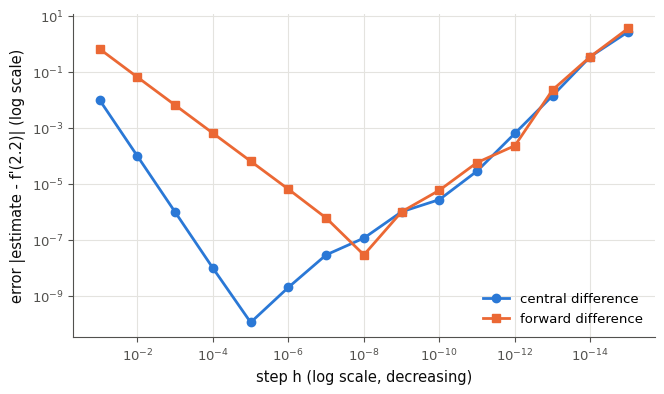

your predictions: a) k = 5   b) k = 8   c) True   d) True


In [14]:
if any(answer is ... or answer is None for answer in [prediction_5_12a, prediction_5_12b, prediction_5_12c, prediction_5_12d]):
    print("⏳ Ex 5.12 : écris d'abord tes quatre prédictions, puis relance cette cellule.")
else:
    steps_12 = 10.0 ** -KS_12
    central_12 = [abs((f_12(X_12 + h) - f_12(X_12 - h)) / (2 * h) - df_12(X_12)) for h in steps_12]
    forward_12 = [abs((f_12(X_12 + h) - f_12(X_12)) / h - df_12(X_12)) for h in steps_12]
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.loglog(steps_12, central_12, "o-", label="central difference")
    ax.loglog(steps_12, forward_12, "s-", label="forward difference")
    ax.invert_xaxis()                                       # h decreases from left to right
    ax.set(xlabel="step h (log scale, decreasing)", ylabel="error |estimate - f'(2.2)| (log scale)")
    ax.legend()
    plt.show()
    print(f"your predictions: a) k = {prediction_5_12a}   b) k = {prediction_5_12b}   "
          f"c) {prediction_5_12c}   d) {prediction_5_12d}")

**Ce qu'il faut retenir.** Les deux courbes descendent d'abord en ligne droite : c'est l'erreur de troncature, en $h^2$ pour la différence centrée (pente 2 en échelle log-log) et en $h$ pour la différence avant (pente 1). Puis elles remontent, de façon irrégulière : c'est l'erreur d'arrondi, qui grandit comme $\varepsilon/h$. Le meilleur pas est vers $h = 10^{-5}$ pour la différence centrée et vers $10^{-8}$ pour la différence avant : la troncature de la différence avant diminue plus lentement, elle reste plus longtemps la plus grande des deux erreurs. À son meilleur pas, la différence centrée est plus de cent fois plus précise. Et un pas minuscule est un désastre : avec $h = 10^{-15}$, l'erreur dépasse celle de $h = 0{,}1$.

💡 Le dilemme du pas est général : l'erreur totale est la somme d'une troncature qui baisse avec $h$ et d'un arrondi qui monte. C'est pourquoi `numerical_derivative` prend $h = 10^{-5}$ par défaut (le bon ordre de grandeur pour la différence centrée, à une fonction près), et pourquoi les *gradient checks* du ch. 18 se font en `float64`.

### Ex 5.13 — Erreur de troncature contre erreur d'arrondi 🔬 ★★ ⏱️ 25 min
**Objectif :** mesurer les deux erreurs d'une différence finie, et retrouver le meilleur pas en minimisant un modèle de l'erreur.  
**Prérequis :** Ex 5.12 · ∂ 5.6 · fiche, au-delà du livre (2) · **Fil rouge :** synthétique · **Parcours :** M, C

Mesure maintenant la courbe de 5.12 avec **ta** fonction `numerical_derivative`. Écris `errors_13(f, df, x, ks, method)`, qui renvoie le tableau des erreurs $|\text{pente estimée} - f'(x)|$ pour les pas $h = 10^{-k}$, $k$ parcourant `ks` (`df` est la dérivée exacte, une fonction ; attention, `10 ** -k` refuse un exposant entier négatif de NumPy : écris `10.0 ** -k`). La cellule de vérification l'appelle sur `f_12` en $x = 2{,}2$, pour $k = 1, \ldots, 15$, et en tire :
a) le $k$ du meilleur pas, pour la différence centrée ;
b) le même, pour la différence avant ;
c) la **pente** de la courbe d'erreur centrée entre $h = 10^{-1}$ et $h = 10^{-3}$, en coordonnées logarithmiques : $\frac{\log_{10} e(10^{-1}) - \log_{10} e(10^{-3})}{\log_{10} 10^{-1} - \log_{10} 10^{-3}}$ ;
d) la même pente, pour la différence avant ;
puis elle trace tes deux courbes.

Ensuite, un modèle simple de l'erreur totale. Avec un pas $h$, l'erreur de troncature de la différence centrée se comporte comme $h^2$, et son erreur d'arrondi comme $\frac{\varepsilon}{h}$, où $\varepsilon \approx 2{,}2 \times 10^{-16}$ (`np.finfo(float).eps`) ; pour la différence avant, comme $h$ et $\frac{\varepsilon}{h}$ (∂ 5.6, question 7 ; on oublie les constantes). Le meilleur pas minimise la somme : annule sa dérivée par rapport à $h$ (§5.3).
e) `log_h_central_13` : $\log_{10}$ du pas qui minimise $h^2 + \frac{\varepsilon}{h}$ (2 décimales) ;
f) `log_h_forward_13` : $\log_{10}$ du pas qui minimise $h + \frac{\varepsilon}{h}$ (2 décimales).

Dans tes notes : que disent les pentes c) et d) de la façon dont l'erreur de troncature diminue ? Le modèle de e) et f) retrouve-t-il les meilleurs pas mesurés en a) et b) ? Pourquoi la partie des petits pas est-elle si irrégulière ?

5 8 2.0000003014187726 1.0032325350249953 -5.318196590063668 -7.826779887263511


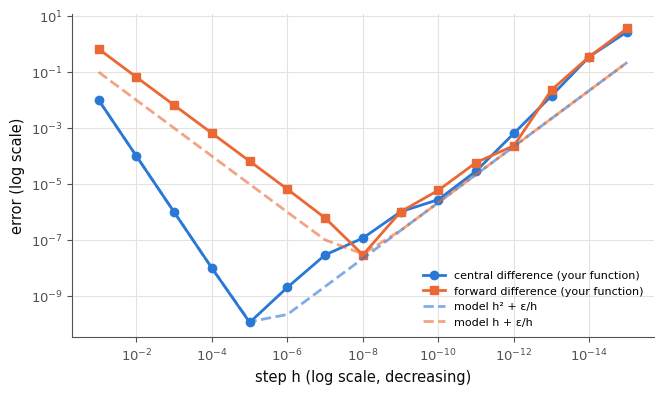

In [15]:
def errors_13(f, df, x, ks, method):
    """|numerical_derivative(f, x, h=10**-k, method) - df(x)| for every k of ks, with YOUR function (an array)."""
    return np.array([abs(mylearn.calculus.numerical_derivative(f, x, h=10.0 ** -k, method=method) - df(x)) for k in ks])


central_13 = errors_13(f_12, df_12, X_12, KS_12, "central")
forward_13 = errors_13(f_12, df_12, X_12, KS_12, "forward")
best_central_13, best_forward_13 = int(KS_12[np.argmin(central_13)]), int(KS_12[np.argmin(forward_13)])
slope_central_13 = float((np.log10(central_13[0]) - np.log10(central_13[2])) / 2)
slope_forward_13 = float((np.log10(forward_13[0]) - np.log10(forward_13[2])) / 2)
eps = np.finfo(float).eps
log_h_central_13 = float(np.log10((eps / 2) ** (1 / 3)))    # 2h - eps/h² = 0  ->  h³ = eps / 2
log_h_forward_13 = float(np.log10(np.sqrt(eps)))           # 1 - eps/h² = 0   ->  h² = eps
print(best_central_13, best_forward_13, slope_central_13, slope_forward_13, log_h_central_13, log_h_forward_13)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
steps_13 = 10.0 ** -KS_12
eps_13 = np.finfo(float).eps
ax.loglog(steps_13, central_13, "o-", label="central difference (your function)")
ax.loglog(steps_13, forward_13, "s-", label="forward difference (your function)")
ax.loglog(steps_13, steps_13 ** 2 + eps_13 / steps_13, "--", color="C0", alpha=0.6, label="model h² + ε/h")
ax.loglog(steps_13, steps_13 + eps_13 / steps_13, "--", color="C1", alpha=0.6, label="model h + ε/h")
ax.invert_xaxis()
ax.set(xlabel="step h (log scale, decreasing)", ylabel="error (log scale)")
ax.legend(fontsize=8)
plt.show()

In [16]:
wb.record("5.13a", best_central_13, mistakes={"15 donne la plus GRANDE erreur (ou la plus négative, si tu as oublié la valeur absolue) : on cherche la plus petite erreur |estimation − f'(x)|": 15})
wb.record("5.13b", best_forward_13, mistakes={"c'est le meilleur pas de la différence CENTRÉE : errors_13 doit transmettre `method` à numerical_derivative": best_central_13,
                                              "15 donne la plus GRANDE erreur (ou la plus négative, si tu as oublié la valeur absolue) : on cherche la plus petite erreur |estimation − f'(x)|": 15})
wb.record("5.13c", slope_central_13, decimals=4)
wb.record("5.13d", slope_forward_13, decimals=4, mistakes={"c'est la pente de la différence CENTRÉE : errors_13 doit transmettre `method` à numerical_derivative": slope_central_13})
wb.record("5.13e", log_h_central_13, decimals=2, mistakes={"c'est log₁₀(ε^(1/3)) : la dérivée de h² + ε/h est 2h − ε/h², elle s'annule pour h³ = ε/2": float(np.log10(eps ** (1 / 3))),
                                                            "c'est log₁₀(√ε), le meilleur pas de la différence AVANT (f) : ici, la troncature est en h²": log_h_forward_13})
wb.record("5.13f", log_h_forward_13, decimals=2, mistakes={"c'est log₁₀(√(2ε)) : la dérivée de h + ε/h est 1 − ε/h², elle s'annule pour h² = ε, sans facteur 2": float(np.log10(np.sqrt(2 * eps))),
                                                            "c'est log₁₀(ε) : le meilleur pas n'est pas ε, il annule la dérivée 1 − ε/h²": float(np.log10(eps)),
                                                            "c'est le meilleur pas de la différence CENTRÉE (e) : ici, la troncature est en h": log_h_central_13})

WB_ANSWER {"hash": "72504bd7564a54069b58ed9f007954dc973e5c1ad0596e80d9ccb117a52cce07", "id": "5.13a", "kind": "int", "magnitude": 0, "mistakes": {"16d156e6488db52ea5c64f4b4cd56748ab69226e8e865dfc6bba3dddbb3b7eff": "15 donne la plus GRANDE erreur (ou la plus négative, si tu as oublié la valeur absolue) : on cherche la plus petite erreur |estimation − f'(x)|"}, "sign": 1}


📝 Ex 5.13a : réponse enregistrée (int).
WB_ANSWER {"hash": "6814516a464214be3b416234ae2fcccc759b19d9c5d843713822c60a09a3205a", "id": "5.13b", "kind": "int", "magnitude": 0, "mistakes": {"dfbce4f4895a854545ee0032d6dbec51a39f1bcefbb9d395ae00b91374f28d17": "15 donne la plus GRANDE erreur (ou la plus négative, si tu as oublié la valeur absolue) : on cherche la plus petite erreur |estimation − f'(x)|", "f3a7837182c9e3d2835d36de72edcbfb4dacd6b3b02882cae591a6ef5de28e32": "c'est le meilleur pas de la différence CENTRÉE : errors_13 doit transmettre `method` à numerical_derivative"}, "sign": 1}
📝 Ex 5.13b : réponse enregistrée (int).
WB_ANSWER {"decimals": 4, "hash": "9a3c8261f557872fe9b8a5914b2749fc4a37c9561c45393749b4b2441d2dfb51", "hash_coarse": "9a5564164bf0d7a4ffac1e4088980a06635ea5c9bf16afcf2dfa7d3fd314074c", "id": "5.13c", "kind": "float", "magnitude": 0, "sign": 1}
📝 Ex 5.13c : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "1f8fa675348bed81b6041b67ab5ecf9

💡 Entre $h = 10^{-1}$ et $10^{-3}$, la courbe centrée a une pente de 2 : diviser $h$ par 10 divise l'erreur par 100 (pour $x^3 - 2x$, l'erreur de troncature vaut même exactement $h^2$, ∂ 5.6). La courbe avant a une pente de 1 (un peu plus, à cause du terme en $h^2$). Le modèle place le meilleur pas en $10^{-5{,}32}$ et $10^{-7{,}83}$ : $k = 5$ et $k = 8$ une fois arrondis, exactement les meilleurs pas mesurés. Les constantes oubliées (ici $|f'''|/6 = 1$ et $|f(2{,}2)| \approx 6{,}2$) déplacent un peu l'optimum, mais pas son ordre de grandeur. Du côté des petits pas, l'erreur d'arrondi dépend des derniers bits de $f(x + h)$ et $f(x - h)$ : elle est irrégulière, presque aléatoire, ce qui rend ces pas inutilisables.

### Ex 5.14 — Les maxima des cycles solaires 🔨 ★★ ⏱️ 30 min
**Objectif :** repérer les extrema locaux d'une série échantillonnée, et mesurer l'effet du lissage et de la largeur de la zone comparée.  
**Prérequis :** Ex 5.11 · Ex 1.12 (taches solaires) · fiche §5.2, §5.3 · livre §5.3 (figures 5.5 et 5.6) · **Fil rouge :** taches solaires · **mylearn :** `calculus.py` · **Parcours :** C

> **mylearn** : dans `mon_travail/mylearn/calculus.py`, mêmes règles qu'en 5.11 (NumPy permis, SciPy et PyTorch non). Enregistre, puis relance la cellule de vérification.

Au ch. 1 (1.12), un outil fourni repérait les sommets de la série lissée des taches solaires. Écris le tien, `find_local_extrema(y, order=1)` (lis sa docstring) : l'échantillon $i$ est un minimum local s'il est **strictement** plus petit que chacun de ses voisins, jusqu'à `order` échantillons de chaque côté (un maximum : strictement plus grand). Les voisins qui tomberaient hors du tableau sont ignorés, mais le premier et le dernier échantillon ne sont jamais des extrema. Renvoie deux tableaux d'indices entiers, triés : les minima, puis les maxima. Lève une `ValueError` si `y` n'est pas à une dimension, ou si `order` n'est pas un entier au moins égal à 1.

C'est la définition « par voisinage » de la fiche (§5.3), pour une courbe échantillonnée : `order` règle la largeur du voisinage. Avec `order=1`, on retrouve les points où la série change de sens, ceux où s'arrête la marche du livre (figures 5.5 et 5.6), sauf sur un palier de valeurs égales (question e). Les données : `raw_14`, les nombres mensuels de taches depuis 1749, et `smooth_14`, leur moyenne mobile **centrée** sur 13 mois (le mois, les 6 précédents et les 6 suivants), sans ses valeurs manquantes ; `dates_14` donne `[année, mois]` pour chaque valeur de `smooth_14`, et `years_14` l'année décimale. La cellule de vérification appelle ta fonction :
a) le nombre de maxima locaux de la série **brute**, avec `order=1` ;
b) le nombre de minima de la série lissée, avec `order=6` ;
c) avec `order=60` (cinq ans de chaque côté), sur la série lissée : `[année, mois]` du dernier minimum, puis du dernier maximum (un tableau 2 × 2) ;
d) avec `order=60`, la plus longue durée entre deux minima successifs, en années ;
puis les tests de `find_local_extrema`, et une figure.

e) `zero_months_14` : le nombre de mois où la série lissée vaut **exactement** 0.

Dans tes notes : la durée de d) correspond-elle à un vrai cycle ? Que s'est-il passé à cette époque, et pourquoi ta fonction ne voit-elle pas le minimum qui manque ? Pourquoi le dernier maximum de c) est-il encore incertain ?

In [17]:
sun_14 = wb.datasets.load_sunspots(definitive_only=True)        # monthly sunspot numbers since 1749 (ch. 1)
raw_14 = sun_14["sunspots"].to_numpy()
centred_14 = sun_14["sunspots"].rolling(13, center=True).mean()  # the month, the 6 before and the 6 after
kept_14 = centred_14.notna().to_numpy()                          # the first 6 and the last 6 months have no value
smooth_14 = centred_14.to_numpy()[kept_14]
years_14 = sun_14["decimal_year"].to_numpy()[kept_14]
dates_14 = sun_14[["year", "month"]].to_numpy()[kept_14]         # [year, month] of every value of smooth_14
print(f"{len(raw_14)} months; {len(smooth_14)} smoothed values, from {dates_14[0].tolist()} to {dates_14[-1].tolist()}")

3327 months; 3315 smoothed values, from [1749, 7] to [2025, 9]


980 63 [[2019, 12], [2024, 10]] 25.083000000000084 9
the longest gap goes from 1798.288 to 1823.371
months at exactly 0: [[1810, 4], [1810, 5], [1810, 6], [1810, 7], [1810, 8], [1810, 9], [1810, 10], [1810, 11], [1810, 12]]


pytest: 17 passed, 89 deselected in 1.72s


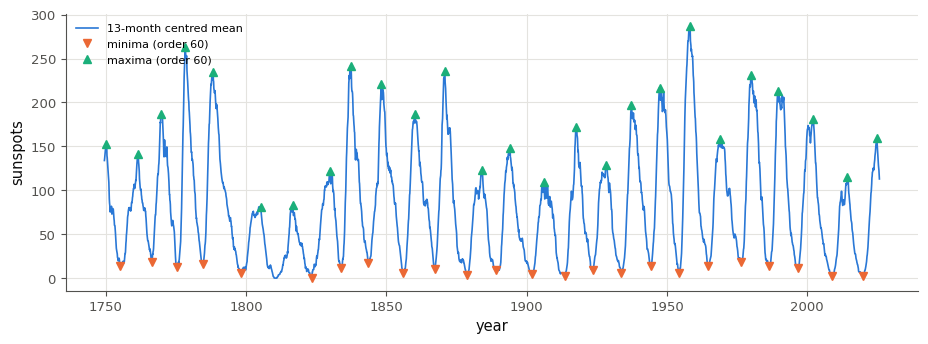

In [18]:
raw_minima_14, raw_maxima_14 = mylearn.calculus.find_local_extrema(raw_14)
minima_6_14, maxima_6_14 = mylearn.calculus.find_local_extrema(smooth_14, order=6)
minima_14, maxima_14 = mylearn.calculus.find_local_extrema(smooth_14, order=60)
last_14 = [dates_14[minima_14[-1]].tolist(), dates_14[maxima_14[-1]].tolist()]
gaps_14 = np.diff(years_14[minima_14])
longest_14 = float(gaps_14.max())
zero_months_14 = int(np.sum(smooth_14 == 0))
print(len(raw_maxima_14), len(minima_6_14), last_14, longest_14, zero_months_14)
print("the longest gap goes from", years_14[minima_14][np.argmax(gaps_14)], "to", years_14[minima_14][np.argmax(gaps_14) + 1])
print("months at exactly 0:", dates_14[smooth_14 == 0].tolist())
run_calculus_tests("test_find_local_extrema_", impl="ref")
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(years_14, smooth_14, lw=1.2, label="13-month centred mean")
ax.plot(years_14[minima_14], smooth_14[minima_14], "v", label="minima (order 60)")
ax.plot(years_14[maxima_14], smooth_14[maxima_14], "^", label="maxima (order 60)")
ax.set(xlabel="year", ylabel="sunspots")
ax.legend(loc="upper left", fontsize=8)
plt.show()

In [19]:
def non_strict_minima_14(y, order):
    """The minima with <= instead of <: a plateau gives several minima (the wrong definition, for the mistakes)."""
    return np.array([i for i in range(1, len(y) - 1)
                     if all(y[i] <= y[j] for j in range(max(0, i - order), min(len(y), i + order + 1)) if j != i)])


def non_strict_maxima_14(y, order):
    """The maxima with >= instead of >: the wrong definition, for the mistakes."""
    return np.array([i for i in range(1, len(y) - 1)
                     if all(y[i] >= y[j] for j in range(max(0, i - order), min(len(y), i + order + 1)) if j != i)])


wb.record("5.14a", len(raw_maxima_14), mistakes={"c'est le nombre de MINIMA (le premier tableau renvoyé) : on demande les maxima": len(raw_minima_14),
                                                 "tes comparaisons ne sont pas strictes : deux mois égaux côte à côte ne sont pas des maxima (relis la docstring)": len(non_strict_maxima_14(raw_14, 1))})
wb.record("5.14b", len(minima_6_14), mistakes={"c'est le nombre de MAXIMA (le second tableau renvoyé) : on demande les minima": len(maxima_6_14),
                                               "c'est le nombre de minima avec order=1 : ta fonction doit comparer chaque point à ses `order` voisins de chaque côté": len(mylearn.calculus.find_local_extrema(smooth_14)[0]),
                                               "tes comparaisons ne sont pas strictes : un plateau ne donne aucun minimum (relis la docstring)": len(non_strict_minima_14(smooth_14, 6))})
wb.record("5.14c", last_14, mistakes={"l'ordre demandé : le dernier minimum, puis le dernier maximum": last_14[::-1]})
wb.record("5.14d", longest_14, decimals=4, mistakes={"tes comparaisons ne sont pas strictes : sur un plateau, aucun point n'est strictement plus petit que ses voisins, il n'y a pas d'extremum (relis la docstring)": float(np.max(np.diff(years_14[non_strict_minima_14(smooth_14, 60)])))})
wb.record("5.14e", zero_months_14, mistakes={"c'est le nombre de mois BRUTS à 0 : on demande la série lissée, smooth_14": int(np.sum(raw_14 == 0))})

WB_ANSWER {"hash": "a2e2bcc9c561aec2777c48269abd292a47f3bce8cce7c39a70ed6aa4d76dbf38", "id": "5.14a", "kind": "int", "magnitude": 2, "mistakes": {"c9c673834abf885dcbedd1bd842d7d39ccbc970c745c289080d6c18f9460cf99": "tes comparaisons ne sont pas strictes : deux mois égaux côte à côte ne sont pas des maxima (relis la docstring)", "fce9f2f1aa830b1b6ad88219be9c4897a65cf4b282ab6b6fe958cd002c95e669": "c'est le nombre de MINIMA (le premier tableau renvoyé) : on demande les maxima"}, "sign": 1}
📝 Ex 5.14a : réponse enregistrée (int).
WB_ANSWER {"hash": "2d235be4d8fb224e5aca7957856eeb5d758ba284d3f319d12dba2462971872da", "id": "5.14b", "kind": "int", "magnitude": 1, "mistakes": {"34317356210e81d9e928008520ff1761d54c213212c497a22f1b5419567bd730": "c'est le nombre de MAXIMA (le second tableau renvoyé) : on demande les minima", "a9dae2cd351d6e3a028340ee3b8ffc56b38446b69ac61897785bd85ebedc9750": "c'est le nombre de minima avec order=1 : ta fonction doit comparer chaque point à ses `order` voisins de 

💡 Sur la série brute, le bruit crée des centaines de « sommets » : un point plus haut que ses deux voisins immédiats n'a rien d'un maximum du cycle. Le lissage et une zone plus large (`order=60`, cinq ans de chaque côté) ne gardent que les vrais extrema : le premier minimum tombe en 1755, au début du cycle que l'on numérote 1, et le dernier en décembre 2019, au début du cycle 25, en cours. Le dernier maximum (octobre 2024) n'a que 11 mois lissés après lui : les mois à venir pourraient encore le dépasser. La durée de 25 ans de d) n'est pas un cycle : c'est le **minimum de Dalton**, où la série lissée vaut exactement 0 pendant neuf mois de 1810. Sur ce plateau, aucun mois n'est strictement plus bas que ses voisins : la définition stricte ne voit pas de minimum, et deux cycles fusionnent. Pour le voir, il faudrait traiter les plateaux (par exemple, garder le milieu d'une suite de valeurs égales), ce que fait `scipy.signal.find_peaks` avec les maxima.

## Partie B · Le gradient : le calculer, le déboguer, le lire sur une carte

Fiche §5.4. Tu écris le gradient numérique et tu l'essaies sur la vallée de Rosenbrock et sur une matrice de poids, tu débogues la version d'un collègue, puis tu lis le gradient sur une carte de lignes de niveau.

### Ex 5.15 — numerical_gradient sur la vallée de Rosenbrock 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire le gradient numérique d'une fonction de plusieurs variables, pour un point de forme quelconque, sans toucher au point reçu.  
**Prérequis :** Ex 5.11 · ✏️ 5.2 · fiche §5.4 (calculer un gradient sur ordinateur) · **Fil rouge :** Rosenbrock · **mylearn :** `calculus.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/calculus.py`, mêmes règles qu'en 5.11 (NumPy permis, SciPy et PyTorch non). Enregistre, puis relance la cellule de vérification.

Écris `numerical_gradient(f, x, h=1e-5)` (lis sa docstring) : pour chaque position $i$ de `x`, la différence centrée $\frac{f(\mathbf{x} + h\,\mathbf{e}_i) - f(\mathbf{x} - h\,\mathbf{e}_i)}{2h}$, où $\mathbf{e}_i$ vaut 1 à la position $i$ et 0 ailleurs.
- Travaille sur une **copie en flottants** : `point = np.array(x, dtype=float)` (contrairement à `np.asarray`, `np.array` copie toujours). Le tableau de l'appelant ne doit jamais changer, pas même pendant les appels à `f`.
- `x` peut avoir n'importe quelle forme : une matrice de poids, par exemple. `point.reshape(-1)` en donne une vue à plat (modifier la vue modifie `point`), et `np.zeros_like(point)` prépare un gradient de la même forme.
- Pour chaque position : garde l'ancienne valeur, pose `ancienne + h`, évalue `f`, pose `ancienne - h`, évalue `f`, puis **remets l'ancienne valeur** telle quelle (ne la recalcule pas : `+ h`, `- 2 * h` puis `+ h` ne redonnent pas toujours exactement le même nombre).

La cellule de vérification appelle ta fonction :
a) le gradient de la fonction de Rosenbrock (`rosenbrock`, $a = 1$, $b = 100$) au point $(-0{,}5 ;\ 0{,}5)$ ; elle le compare au gradient exact, `rosenbrock_gradient` ;
b) le gradient de la loss $L(\mathbf{W}) = \sum_i \big((\mathbf{W}\mathbf{v})_i - t_i\big)^2$ (`loss_15`) par rapport à la **matrice** $\mathbf{W}$, au point `W_15` (une matrice 2 × 3) ;
puis le contrôle que `W_15` n'a pas changé, et les tests de `numerical_gradient`.

Dans tes notes : combien d'appels à `loss_15` a-t-il fallu pour b) ? Vérifie b) à la main avec la formule $\nabla_{\mathbf{W}} L = 2\,(\mathbf{W}\mathbf{v} - \mathbf{t})\,\mathbf{v}^\top$ (0B).

In [20]:
W_15 = np.array([[1.0, 0.0, -1.0],
                 [0.5, 2.0, 0.0]])
V_15 = np.array([1.0, 2.0, 3.0])
T_15 = np.array([0.0, 1.0])


def loss_15(W):
    """Sum of the squared errors of W @ V_15 against the targets T_15: a function of the matrix W."""
    return float(np.sum((W @ V_15 - T_15) ** 2))

In [21]:
grad_15 = mylearn.calculus.numerical_gradient(rosenbrock, [-0.5, 0.5])
calls_15 = []
grad_W_15 = mylearn.calculus.numerical_gradient(lambda W: calls_15.append(1) or loss_15(W), W_15)
by_hand_15 = 2 * np.outer(W_15 @ V_15 - T_15, V_15)
print(grad_15, rosenbrock_gradient([-0.5, 0.5]))
print(grad_W_15.round(6), f"{len(calls_15)} calls of the loss", np.allclose(grad_W_15, by_hand_15), sep="\n")
run_calculus_tests("test_numerical_gradient_", impl="ref")

[46.99999998 50.        ] [47. 50.]
[[ -4.  -8. -12.]
 [  7.  14.  21.]]
12 calls of the loss
True


pytest: 16 passed, 90 deselected in 1.76s


In [22]:
wb.record("5.15a", grad_15, decimals=4, mistakes={"tu as divisé par h au lieu de 2h : les deux points sont à 2h l'un de l'autre": 2 * grad_15,
                                                   "l'ordre est [∂f/∂x, ∂f/∂y]": grad_15[::-1]})
wb.record("5.15b", grad_W_15, decimals=4, mistakes={"tu as divisé par h au lieu de 2h": 2 * grad_W_15})

WB_ANSWER {"decimals": 4, "element_coarse": [["f2e5b7dc805ac168e0be700d0fe78e9a2d523e4705487bca83dae2ffd58f815b"], ["41505d2eda40a47766f922b57c82de69f7f3a619bd7a76fbdbf12ce2521ce848"]], "element_hashes": ["5c0d70ed52def9f652ae78f7b3163ed926e2f77fa6c0e92d685f975d86734316", "c3b2942601518557beaf2c588402d8c9564845e0437863d7fc2f511244eb586d"], "hash": "4cda02ad3da99ed73692d52cf87e350c605e85778de81c3dec71d547e62137de", "id": "5.15a", "kind": "array", "mistakes": {"3419d8816b43e1754be3c2f8550d3c8e3cfaf57efef9d261823346c05cd0926d": "l'ordre est [∂f/∂x, ∂f/∂y]", "9c85a7ee50b9f5e9d4600b319e40cae241b85db7e2dda089bc2af53c267d2796": "tu as divisé par h au lieu de 2h : les deux points sont à 2h l'un de l'autre"}, "shape": [2]}
📝 Ex 5.15a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "element_coarse": [["e901fa8cbfe9db6fb24464580575ed755c1b5189e6725746ec62b60f33c0bb2f"], ["7f6283cf6d4be98773372b8d69647221f15c38281ae5806f6ac741e8fcae15ac"], ["0c21af11630587114bcbeee926057e68

💡 Il faut deux évaluations par coordonnée : 4 pour a), 12 pour b), et $2n$ pour $n$ paramètres (🧮 5.9). Le gradient de b) a la forme de $\mathbf{W}$ : chaque poids reçoit sa dérivée partielle. À la main, $\mathbf{W}\mathbf{v} = (-2 ;\ 4{,}5)$, donc $\mathbf{W}\mathbf{v} - \mathbf{t} = (-2 ;\ 3{,}5)$ et $2\,(\mathbf{W}\mathbf{v} - \mathbf{t})\,\mathbf{v}^\top$ redonne exactement b). En $(-0{,}5 ;\ 0{,}5)$, la pente de Rosenbrock est déjà forte : la vallée $y = x^2$ passe juste en dessous, en $y = 0{,}25$.

### Ex 5.16 — Le gradient qui abîme son entrée 🐛 ★★ ⏱️ 20 min
**Objectif :** comprendre pourquoi un gradient numérique doit travailler sur une copie en flottants, et corriger la version d'un collègue.  
**Prérequis :** Ex 5.15 · fiche §5.4 et les pièges classiques · **Fil rouge :** Rosenbrock · **Parcours :** C

Un collègue a écrit son propre gradient numérique, `gradient_colleague` (cellule ci-dessous). Il l'a essayé sur des points à virgule, comme $(0{,}1 ;\ 0{,}2)$ : les valeurs sont justes. Puis il lance une descente de gradient depuis le point $(-1, 1)$, écrit sans virgule, `np.array([-1, 1])`. La cellule affiche ce que renvoie sa fonction dans les deux cas.

a) `exact_16` : le vrai gradient de Rosenbrock en $(-1, 1)$ (une liste ; avec `rosenbrock_gradient`, ou à la main avec ∂ 5.7) ;
b) `after_16` : que contient `start_16` **après** l'appel de la cellule ? (une liste de deux entiers : affiche-le) ;
c) `changed_16` : crée un point à virgule, `point_16 = np.array([0.1, 0.2])`, et appelle **une fois** `gradient_colleague(rosenbrock, point_16)`. Combien de ses deux coordonnées ont changé ? (un entier ; compare-les aux valeurs d'origine avec `==` : `print` arrondit l'affichage) ;
d) corrige : écris `gradient_fixed_16(f, x, h=1e-5)`, la fonction du collègue en changeant le moins de lignes possible. La vérification l'appelle sur le point entier $(-1, 1)$ (le gradient obtenu est vérifié) et sur un point à virgule, et contrôle qu'aucun des deux points n'est modifié.

Dans tes notes : explique les deux défauts de la fonction du collègue, et pourquoi il ne voyait rien sur ses points à virgule. Le défaut de c) est minuscule : pourquoi est-il quand même dangereux ?

In [23]:
def gradient_colleague(f, x, h=1e-5):
    """The colleague's numerical gradient: central differences, one coordinate after the other."""
    x = np.asarray(x)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x[i] += h
        f_plus = f(x)
        x[i] -= 2 * h
        f_minus = f(x)
        x[i] += h
        grad[i] = (f_plus - f_minus) / (2 * h)
    return grad


print("gradient at (0.1, 0.2):", gradient_colleague(rosenbrock, np.array([0.1, 0.2])))
start_16 = np.array([-1, 1])                    # the starting point of a descent, written without decimal points
print("gradient at (-1, 1):   ", gradient_colleague(rosenbrock, start_16))

gradient at (0.1, 0.2): [-9.4 38. ]
gradient at (-1, 1):    [      0 5000000]


In [24]:
exact_16 = rosenbrock_gradient([-1.0, 1.0]).tolist()
after_16 = start_16.tolist()
point_16 = np.array([0.1, 0.2])
gradient_colleague(rosenbrock, point_16)
changed_16 = int(np.sum(point_16 != np.array([0.1, 0.2])))
print(exact_16, after_16, changed_16, repr(point_16[0]), repr(point_16[1]))


def gradient_fixed_16(f, x, h=1e-5):
    """The colleague's function, corrected: the same gradient for [-1, 1] as for [-1.0, 1.0], x never modified."""
    x = np.array(x, dtype=float)          # the only change: a float COPY (np.zeros_like(x) is then float too)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        x[i] += h
        f_plus = f(x)
        x[i] -= 2 * h
        f_minus = f(x)
        x[i] += h
        grad[i] = (f_plus - f_minus) / (2 * h)
    return grad


fixed_16 = gradient_fixed_16(rosenbrock, np.array([-1, 1]))
print(fixed_16)

[-4.0, 0.0] [0, 0] 2 np.float64(0.09999999999999999) np.float64(0.20000000000000004)
[-4.00000004  0.        ]


In [25]:
wb.record("5.16a", exact_16, mistakes={"c'est le résultat du collègue : calcule le gradient exact, avec rosenbrock_gradient ou ∂ 5.7": [0, 5000000]})
wb.record("5.16b", after_16, mistakes={"regarde vraiment : affiche start_16 après l'appel, il a changé": [-1, 1]})
wb.record("5.16c", changed_16, mistakes={"print arrondit l'affichage : compare avec ==, par exemple point_16 == np.array([0.1, 0.2])": 0})
wb.record("5.16d", fixed_16, decimals=4, mistakes={"le point est encore un tableau d'ENTIERS : chaque décalage de h est tronqué (convertis avec dtype=float)": [0, 5000000]})

WB_ANSWER {"decimals": 0, "element_hashes": ["e933d33f18198157733f39b2f5cec50c0ab28be09504d6da2b0b56f447b8d730", "78f13f9ab89c016524c988904c6c0ebf2918b5803c898e415ecc3a66f93f33ea"], "hash": "d1c14eebb346254419c2cc8924ebc9b4e74eab30d2807a9658fbd3d3d45cc790", "id": "5.16a", "integer": true, "kind": "array", "mistakes": {"074c49c1557e90e69b80a21cb01a2dda13d0ab19f8855e23c4d4ed5812a09269": "c'est le résultat du collègue : calcule le gradient exact, avec rosenbrock_gradient ou ∂ 5.7"}, "shape": [2]}
📝 Ex 5.16a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 0, "element_hashes": ["09c812035a8d1db9f854128cfa0b91d28e87697f850d75b88426fee846654160", "19fb77f9072eb36b08c9c840e206ebeb1be0b7c008d3fa010d2d77f41833d1b8"], "hash": "d396ea01d3e755cbaf5e2265f8e916ec7923caefe385f78b6197d8f58cb4bb66", "id": "5.16b", "integer": true, "kind": "array", "mistakes": {"88bae7e991f1488c84d2badb62b443daa72774819eb608e69b4279a5d061fa34": "regarde vraiment : affiche start_16 après l'appel, il a

💡 Deux défauts. (1) `np.asarray(x)` ne copie pas : la fonction modifie le tableau de l'appelant. (2) Elle garde son type : avec un tableau d'entiers, `x[i] += h` donne $-1 + 10^{-5} = -0{,}99999$, arrondi vers zéro en l'entier 0 ; le point devient $(0, 0)$, les « dérivées » sont absurdes, et le gradient lui-même est un tableau d'entiers. Sur des flottants, le calcul est juste, et le tableau ne bouge que d'un arrondi (`0.09999999999999999` au lieu de `0.1`) : invisible à l'affichage, mais une descente de gradient qui partage ce tableau avec son appelant s'en trouve modifiée en douce, et un test d'égalité exacte échoue sans raison apparente. Une seule ligne corrige les deux défauts : `x = np.array(x, dtype=float)`, une copie en flottants. Garder l'ancienne valeur et la remettre telle quelle, comme en 5.15, évite en plus la petite dérive de la copie.

### Ex 5.17 — Lire des lignes de niveau : où pointe le gradient ? 📈 ★★ ⏱️ 20 min
**Objectif :** lire sur une carte de lignes de niveau les extrema, les points selles, la pente et la direction du gradient.  
**Prérequis :** Ex 5.15 · ✏️ 5.2, 5.5 · fiche §5.4 (pente dans une direction, lignes de niveau, points critiques) · **Fil rouge :** synthétique · **Parcours :** R, M

La carte ci-dessous représente $g(x, y) = x^3 - 3x - y^3 + 3y$ par ses **lignes de niveau** : les couleurs claires sont hautes, les sombres basses (voir la barre de couleurs). Six points sont marqués de A à F. **Sans calculer de dérivée** (sauf en f), lis la carte :
a) `max_17` : la lettre du maximum local ;
b) `min_17` : la lettre du minimum local ;
c) `saddles_17` : les lettres des points selles (un ensemble de chaînes, par exemple `{"X", "Y"}`) ;
d) `steeper_17` : en lequel des deux points D et F la pente est-elle la plus forte ? (`"D"` ou `"F"`) ;
e) `uphill_D_17` : en D, vers où la montée est-elle la plus raide ? Une des huit directions de la boussole, le nord en haut : `"N"`, `"NE"`, `"E"`, `"SE"`, `"S"`, `"SO"`, `"O"` (ouest) ou `"NO"` ;
f) `grad_F_17` : enfin, calcule le gradient de $g$ en F (une liste, 2 décimales), avec les coordonnées de F affichées sous la carte.

Une fois tes six réponses écrites, la dernière cellule superpose à la carte les flèches du gradient : regarde leur longueur, leur sens, et leur angle avec les lignes de niveau.

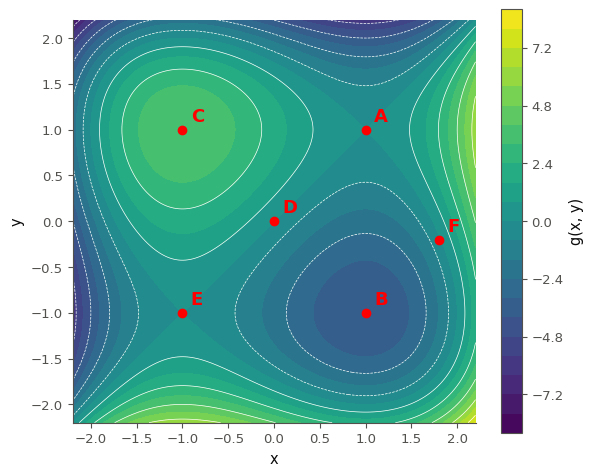

F = (1.8, -0.2)


In [26]:
def g_17(x, y):
    """x³ - 3x - y³ + 3y (works on grids of points)."""
    return x ** 3 - 3 * x - y ** 3 + 3 * y


POINTS_17 = {"A": (1.0, 1.0), "B": (1.0, -1.0), "C": (-1.0, 1.0), "D": (0.0, 0.0), "E": (-1.0, -1.0), "F": (1.8, -0.2)}
X_17, Y_17 = np.meshgrid(np.linspace(-2.2, 2.2, 201), np.linspace(-2.2, 2.2, 201))


def draw_map_17(ax):
    """Filled level lines of g_17 (light = high), the lines themselves and the six points; returns the colour map."""
    colours = ax.contourf(X_17, Y_17, g_17(X_17, Y_17), levels=24, cmap="viridis")
    ax.contour(X_17, Y_17, g_17(X_17, Y_17), levels=colours.levels[::2], colors="white", linewidths=0.5)
    for letter, (x, y) in POINTS_17.items():
        ax.plot(x, y, "o", color="red")
        ax.annotate(letter, (x, y), xytext=(6, 6), textcoords="offset points", color="red", fontsize=13,
                    weight="bold")
    ax.set_aspect("equal")
    ax.set(xlabel="x", ylabel="y")
    return colours


fig, ax = plt.subplots(figsize=(6.5, 5.5))
fig.colorbar(draw_map_17(ax), ax=ax, label="g(x, y)")
plt.show()
print("F =", POINTS_17["F"])

In [27]:
max_17, min_17, saddles_17, steeper_17, uphill_D_17 = "C", "B", {"A", "E"}, "F", "NO"
x_F, y_F = POINTS_17["F"]
grad_F_17 = [3 * x_F ** 2 - 3, -3 * y_F ** 2 + 3]
print(grad_F_17, "norm at F:", np.hypot(*grad_F_17), "norm at D:", np.hypot(-3, 3))

[6.720000000000001, 2.88] norm at F: 7.311142181629353 norm at D: 4.242640687119285


In [28]:
wb.record("5.17a", max_17, mistakes={"c'est le minimum : les couleurs claires sont les hauteurs": "B",
                                      "A est un point selle : la surface y monte dans une direction et descend dans l'autre": "A",
                                      "E est un point selle : la surface y monte dans une direction et descend dans l'autre": "E"})
wb.record("5.17b", min_17, mistakes={"c'est le maximum : les couleurs sombres sont les creux": "C",
                                     "A est un point selle, pas un creux : la surface y monte dans une direction et descend dans l'autre": "A",
                                     "E est un point selle, pas un creux : la surface y monte dans une direction et descend dans l'autre": "E"})
wb.record("5.17c", saddles_17, mistakes={"il y a deux points selles : là où les lignes de niveau se croisent en X": {"A"},
                                         "il y a deux points selles : regarde aussi l'autre croisement en X": {"E"},
                                         "D n'est pas un point critique : les lignes de niveau y sont régulières, le gradient n'y est pas nul": {"A", "E", "D"}})
wb.record("5.17d", steeper_17, mistakes={"les lignes de niveau sont plus serrées en F : la pente y est plus forte": "D"})
wb.record("5.17e", uphill_D_17, mistakes={"c'est la direction de plus grande DESCENTE : le gradient pointe vers la montée": "SE",
                                          "regarde où sont les couleurs claires autour de D : vers le maximum C": "NE",
                                          "c'est la bonne direction, mais écrite en anglais : utilise les initiales françaises (O pour ouest)": "NW",
                                          "le gradient en D a deux composantes non nulles : la direction est une diagonale": "N",
                                          "le gradient en D a deux composantes non nulles : la plus grande montée suit une diagonale": "O"})
wb.record("5.17f", grad_F_17, decimals=2, mistakes={"la dérivée de −y³ est −3y² : ∂g/∂y = −3y² + 3": [6.72, -2.88],
                                                    "n'oublie pas la dérivée de −3x : ∂g/∂x = 3x² − 3": [9.72, 2.88],
                                                    "l'ordre est [∂g/∂x, ∂g/∂y]": [2.88, 6.72]})

WB_ANSWER {"hash": "ee9eef1c25e645e726e67d2d25295447d2fef0c8454f772d83a1f331592a70ff", "id": "5.17a", "kind": "str", "mistakes": {"032385728cac76b7b9b5a2c2b23786fbc5c8db14c81e75a3914fc577503d6a5c": "E est un point selle : la surface y monte dans une direction et descend dans l'autre", "84cd5ef2e9099549901db6725a9d05b0c5358efc411baf9a9bf5a700a906c9a6": "c'est le minimum : les couleurs claires sont les hauteurs", "a7f0cfb847f77f28c0d0bbbe3b630164ca9cbeb01ea32385a072be312392474e": "A est un point selle : la surface y monte dans une direction et descend dans l'autre"}}
📝 Ex 5.17a : réponse enregistrée (str).
WB_ANSWER {"hash": "c18f96efa45bae4949968306ea257dfe12e3f51401df5302e0e160b72a3cffeb", "id": "5.17b", "kind": "str", "mistakes": {"06bb8410ada4c32c72cc64b4d2c0f02096771ccea1df08ee3eed42f1f31e0368": "c'est le maximum : les couleurs sombres sont les creux", "3b7226db470b5920bdaf83a32041be624702a2f9e04d8f5d581947067fd0505c": "E est un point selle, pas un creux : la surface y monte dans un

**La carte et ses gradients** : exécute la cellule une fois tes six réponses écrites.

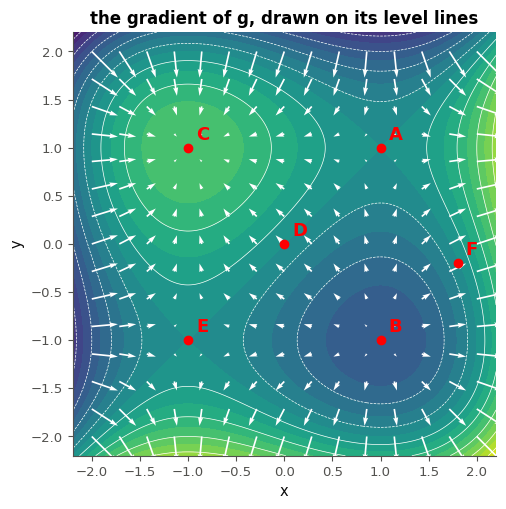

In [29]:
if any(answer is ... or answer is None for answer in [max_17, min_17, saddles_17, steeper_17, uphill_D_17, grad_F_17]):
    print("⏳ Ex 5.17 : écris d'abord tes six réponses, puis relance cette cellule.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    draw_map_17(ax)
    GX_17, GY_17 = np.meshgrid(np.linspace(-2, 2, 15), np.linspace(-2, 2, 15))
    ax.quiver(GX_17, GY_17, 3 * GX_17 ** 2 - 3, -3 * GY_17 ** 2 + 3, color="white")   # the gradient at each point
    ax.set_title("the gradient of g, drawn on its level lines")
    plt.show()

💡 Le gradient $(3x^2 - 3,\ -3y^2 + 3)$ s'annule en quatre points : C $(-1, 1)$, le maximum ($g = 4$) ; B $(1, -1)$, le minimum ($g = -4$) ; A et E, deux points selles ($g = 0$), où les lignes de niveau se croisent en X. En D, le gradient vaut $(-3, 3)$ : il pointe vers le nord-ouest, vers C, et sa norme vaut $\sqrt{18} \approx 4{,}24$. En F, il vaut $(6{,}72 ;\ 2{,}88)$, de norme 7,31 : les lignes y sont plus serrées. Partout, les flèches coupent les lignes de niveau à angle droit, et elles sont longues là où les lignes sont serrées (fiche §5.4).

## Partie C · Descendre : le learning rate, les points selles, autograd

Fiche §5.4 et « au-delà du livre » (3). Tu écris la descente de gradient, tu mesures l'effet du learning rate sur un bol, tu prévois ce que fait une descente partie d'un point selle, puis tu compares ton gradient numérique au gradient de PyTorch.

### Ex 5.18 — gradient_descent, et sa version qui monte 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire la descente (et la montée) de gradient, avec le chemin parcouru et un critère d'arrêt.  
**Prérequis :** Ex 5.15 · ✏️ 5.3 · fiche §5.4 (descendre une surface pas à pas) · **Fil rouge :** synthétique · **mylearn :** `calculus.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/calculus.py`, mêmes règles qu'en 5.11 (NumPy permis, SciPy et PyTorch non). Enregistre, puis relance la cellule de vérification.

Écris `gradient_descent(grad, x0, lr=0.01, n_steps=100, tol=None, maximize=False)` (lis sa docstring) :
- lève une `ValueError` si `lr <= 0`, si `n_steps < 0`, ou si `tol` est donné et négatif ;
- pars d'une copie en flottants de `x0`, et range chaque point visité dans une liste (des **copies** : `x.copy()`) ;
- à chaque pas : évalue le gradient au point courant ; si `tol` est donné et que la norme euclidienne de ce gradient (`np.linalg.norm`, sur toutes ses composantes) est **strictement** inférieure à `tol`, arrête-toi sans bouger ; sinon, fais le pas $\mathbf{x} \leftarrow \mathbf{x} - \eta\,\nabla f(\mathbf{x})$, ou $\mathbf{x} + \eta\,\nabla f(\mathbf{x})$ si `maximize` ;
- renvoie le dernier point et le tableau du chemin (`np.array` de la liste), de forme `(nombre de pas faits + 1, *x0.shape)`.

Vérifications sur deux fonctions dont les gradients sont fournis : $q(\mathbf{v}) = (v_0 + 1)^2 + 4\,(v_1 - 0{,}5)^2$, de minimum $(-1 ;\ 0{,}5)$, et $m(\mathbf{v}) = -(v_0 - 1)^2 - 2\,(v_1 + 2)^2$, de maximum $(1 ;\ -2)$. La cellule de vérification appelle ta fonction :
a) le point atteint sur $q$ depuis $(1, 1)$, avec `lr=0.1` et 15 pas ;
b) le nombre de pas faits sur $q$ depuis $(1, 1)$, avec `lr=0.1`, `n_steps=1000` et `tol=1e-3` ;
c) le point atteint en **montant** $m$ depuis $(0, 0)$, avec `lr=0.2` et 3 pas ;
puis deux contrôles, les tests de `gradient_descent`, et la trajectoire de a) sur la carte de $q$.

Dans tes notes : en a), pourquoi $v_1$ est-il déjà au minimum alors que $v_0$ en est encore loin ? Regarde le facteur qui multiplie, à chaque pas, l'écart de chaque coordonnée au minimum (✏️ 5.3).

In [30]:
def grad_q_18(v):
    """Gradient of q(v) = (v0 + 1)² + 4 (v1 - 0.5)²."""
    return np.array([2 * (v[0] + 1), 8 * (v[1] - 0.5)])


def grad_m_18(v):
    """Gradient of m(v) = -(v0 - 1)² - 2 (v1 + 2)²."""
    return np.array([-2 * (v[0] - 1), -4 * (v[1] + 2)])

[-0.92963126  0.5       ] 38 [ 0.784 -1.984]
factors per step: 0.8 for v0 and 0.2 for v1


pytest: 19 passed, 87 deselected in 2.37s


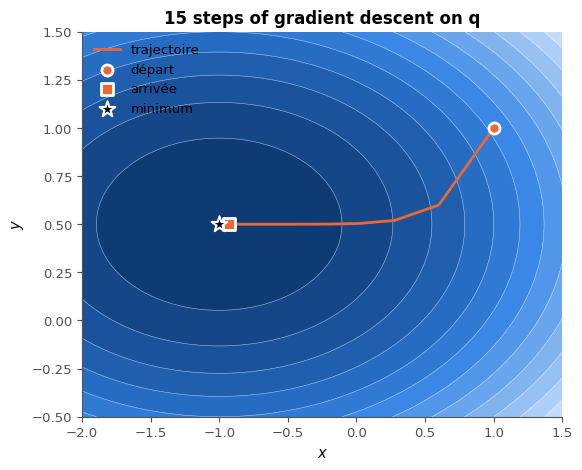

In [31]:
end_18, path_18 = mylearn.calculus.gradient_descent(grad_q_18, [1.0, 1.0], lr=0.1, n_steps=15)
_, stopped_18 = mylearn.calculus.gradient_descent(grad_q_18, [1.0, 1.0], lr=0.1, n_steps=1000, tol=1e-3)
n_done_18 = len(stopped_18) - 1
top_18 = mylearn.calculus.gradient_descent(grad_m_18, [0.0, 0.0], lr=0.2, n_steps=3, maximize=True)[0]
print(end_18, n_done_18, top_18)
print("factors per step:", round(1 - 0.1 * 2, 2), "for v0 and", round(1 - 0.1 * 8, 2), "for v1")
run_calculus_tests("test_gradient_descent_", impl="ref")
wb.plot.plot_contour(lambda x, y: (x + 1) ** 2 + 4 * (y - 0.5) ** 2, xlim=(-2, 1.5), ylim=(-0.5, 1.5),
                     path=path_18, log=False, minimum=(-1, 0.5), levels=15, title="15 steps of gradient descent on q")
plt.show()

In [32]:
wrong_way_18 = mylearn.calculus.gradient_descent(grad_q_18, [1.0, 1.0], lr=0.1, n_steps=15, maximize=True)[0]
wb.record("5.18a", end_18, decimals=4, mistakes={"tu es monté : pour descendre, on RETIRE lr × gradient": wrong_way_18,
                                                 "c'est le point après 14 pas : n_steps pas donnent n_steps + 1 points dans le chemin": mylearn.calculus.gradient_descent(grad_q_18, [1.0, 1.0], lr=0.1, n_steps=14)[0]})
wb.record("5.18b", n_done_18, mistakes={"ta descente fait un pas de trop : teste tol AVANT de bouger, au point courant": n_done_18 + 1,
                                        "tol n'est pas pris en compte : avant chaque pas, arrête-toi si la norme du gradient est < tol": 1000})
wb.record("5.18c", top_18, decimals=4, mistakes={"tu es descendu : avec maximize=True, on AJOUTE lr × gradient": mylearn.calculus.gradient_descent(grad_m_18, [0.0, 0.0], lr=0.2, n_steps=3)[0]})

WB_ANSWER {"decimals": 4, "element_coarse": [["0b449bc0c8988f530828b0997422cb5d26413682f6dfc55084f506d926ffc4f8"], ["b12272dedbd11ad582a9a042243080b9c417cfc5f0b7d51fff5deb4b7d3de750"]], "element_hashes": ["e7ba8f15228362bf04984897cd5e6ea27baa2f60ac35274b50c105faaf689a70", "bce3e6a37e6c7b739e42d75f0dfb475e8e62b122e3c45cce26f0aaae3df4ebb2"], "hash": "a5a10dffae969ad99b7fdfb80b458a18a451e781f7d34d4e7395ea24f36a0022", "id": "5.18a", "kind": "array", "mistakes": {"83c891683c3e4ea3d446b45df37b42d3ae024335ac1d0593e097c5489a5af975": "tu es monté : pour descendre, on RETIRE lr × gradient", "bdceefeab7c40ae5bbbce2b05715b912949bd4f7907e5819d1ebcd9001f3faae": "c'est le point après 14 pas : n_steps pas donnent n_steps + 1 points dans le chemin"}, "shape": [2]}
📝 Ex 5.18a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"hash": "9ee26f603efb2684b9abe3a84beb706ae7ffd441479f8c26cbde5916d1cfbe6b", "id": "5.18b", "kind": "int", "magnitude": 1, "mistakes": {"26e372eb1b37d17d1dc16b0a003b76c237a221

💡 En a), l'écart de $v_0$ au minimum est multiplié par $1 - 2\eta = 0{,}8$ à chaque pas, celui de $v_1$ par $1 - 8\eta = 0{,}2$ : après 15 pas, $0{,}8^{15} \approx 0{,}035$, mais $0{,}2^{15} \approx 3 \times 10^{-11}$. La direction la plus courbée converge le plus vite (fiche, « un learning rate pour plusieurs courbures »). En b), 38 pas suffisent pour que la norme du gradient passe sous $10^{-3}$. La montée de c) est la descente de $-m$ ; le paramètre `maximize` porte le même nom dans `torch.optim.SGD`, l'oracle des tests.

### Ex 5.19 — Learning rate sur un bol : trop petit, juste, trop grand 🔬 ★★ ⏱️ 25 min
**Objectif :** mesurer l'effet du learning rate sur une surface dont les deux directions n'ont pas la même courbure.  
**Prérequis :** Ex 5.18 · Ex 1.17 · ✏️ 5.3 · fiche §5.4 (un learning rate pour plusieurs courbures) · **Fil rouge :** synthétique · **Parcours :** C

Le bol $b(\mathbf{v}) = v_0^2 + 10\,v_1^2$ est dix fois plus courbé selon $v_1$ que selon $v_0$. Avec ta fonction `gradient_descent`, descends-le depuis $(2, 1)$, 50 pas, avec chacun des learning rates de `LRS_19` : 0,01 ; 0,05 ; 0,09 ; 0,1 et 0,11.

Écris `distances_19(lr)` : la distance au minimum $(0, 0)$ de chacun des 51 points du chemin, départ compris (un tableau de 51 nombres ; `np.linalg.norm(..., axis=1)`). La vérification contrôle tes distances avec la formule exacte (à chaque pas, $v_0$ est multiplié par $1 - 2\eta$ et $v_1$ par $1 - 20\eta$, ✏️ 5.3), puis trace les distances pas à pas, en échelle logarithmique, et les cinq trajectoires sur la carte du bol.

Réponds dans la cellule 📝 :
- quels learning rates convergent ? Lequel est le plus rapide, et pourquoi n'est-ce pas le plus grand ?
- que fait la descente avec 0,1 ? avec 0,11 ? Quelle direction fixe le plus grand learning rate possible, et laquelle fixe la vitesse ?
- avec 0,01, combien de pas faudrait-il, à peu près, pour arriver à moins de 0,01 du minimum ?

In [33]:
def grad_bowl_19(v):
    """Gradient of b(v) = v0² + 10 v1²."""
    return np.array([2 * v[0], 20 * v[1]])


START_19 = [2.0, 1.0]
LRS_19 = [0.01, 0.05, 0.09, 0.1, 0.11]

lr = 0.01 : factors +0.98 (v0) and +0.80 (v1); distance after 50 steps 0.728
lr = 0.05 : factors +0.90 (v0) and +0.00 (v1); distance after 50 steps 0.0103
lr = 0.09 : factors +0.82 (v0) and -0.80 (v1); distance after 50 steps 9.91e-05
lr = 0.1  : factors +0.80 (v0) and -1.00 (v1); distance after 50 steps 1
lr = 0.11 : factors +0.78 (v0) and -1.20 (v1); distance after 50 steps 9.1e+03
steps to get within 0.01 with lr = 0.01: 262.25778967521944


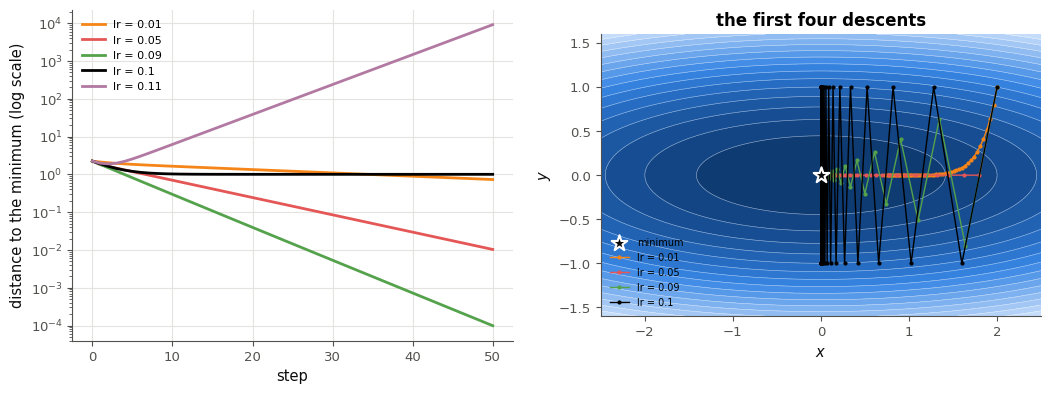

In [34]:
def distances_19(lr):
    """Distances to (0, 0) of the 51 points of 50 steps of YOUR gradient_descent on the bowl, from START_19."""
    _, path = mylearn.calculus.gradient_descent(grad_bowl_19, START_19, lr=lr, n_steps=50)
    return np.linalg.norm(path, axis=1)


curves_19 = {lr: distances_19(lr) for lr in LRS_19}
for lr, curve in curves_19.items():
    print(f"lr = {lr:<5}: factors {1 - 2 * lr:+.2f} (v0) and {1 - 20 * lr:+.2f} (v1); distance after 50 steps {curve[-1]:.3g}")
print("steps to get within 0.01 with lr = 0.01:", np.log(0.01 / 2) / np.log(0.98))
steps_19 = np.arange(51)
colours_19 = dict(zip(LRS_19, ["#f58518", "#e45756", "#54a24b", "#000000", "#b279a2"]))   # one colour per lr
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12.5, 4.3))
for lr, curve in curves_19.items():
    ax_left.semilogy(steps_19, curve, color=colours_19[lr], label=f"lr = {lr}")
ax_left.set(xlabel="step", ylabel="distance to the minimum (log scale)")
ax_left.legend(fontsize=8)
wb.plot.plot_contour(lambda x, y: x ** 2 + 10 * y ** 2, xlim=(-2.5, 2.5), ylim=(-1.6, 1.6), ax=ax_right, log=False,
                     minimum=(0, 0), resolution=150, levels=15)
for lr in LRS_19[:4]:                                     # lr = 0.11 leaves the frame: see the left panel
    path = mylearn.calculus.gradient_descent(grad_bowl_19, START_19, lr=lr, n_steps=50)[1]
    ax_right.plot(path[:, 0], path[:, 1], ".-", color=colours_19[lr], lw=1, ms=4, label=f"lr = {lr}")
ax_right.set(xlim=(-2.5, 2.5), ylim=(-1.6, 1.6), title="the first four descents")
ax_right.set_aspect("equal")
ax_right.legend(fontsize=7, loc="lower left")
plt.show()

💡 Avec 0,01, la descente est sûre mais lente : $v_0$ n'est multiplié que par 0,98 par pas (il reste 0,73 après 50 pas, et il faudrait environ 260 pas pour arriver à 0,01). Avec 0,05, $v_1$ tombe à 0 en un seul pas (facteur $1 - 20\eta = 0$), mais $v_0$ ne gagne qu'un facteur 0,9. Avec 0,09, les deux facteurs valent 0,82 et $-0{,}8$ : $v_1$ oscille en s'amortissant, et c'est le plus rapide. Le meilleur choix égalise les deux facteurs en valeur absolue, $1 - 2\eta = -(1 - 20\eta)$, soit $\eta = 1/11 \approx 0{,}091$. Avec 0,1, le facteur de $v_1$ vaut exactement $-1$ : $v_1$ saute de 1 à $-1$ indéfiniment, et la distance reste bloquée vers 1. Avec 0,11, il vaut $-1{,}2$ : la descente diverge. La direction la plus courbée ($v_1$) fixe le plus grand learning rate possible, la plus plate ($v_0$) fixe la vitesse. C'est tout le problème de la vallée de Rosenbrock (🏆 5.25).

### Ex 5.20 — Démarrer pile sur un point selle 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir ce que fait une descente de gradient partie d'un point selle, ou d'un point très proche.  
**Prérequis :** Ex 5.18 · ✏️ 5.5 · fiche §5.4 (les points où le gradient s'annule, 🕰️ points selles) · **Fil rouge :** synthétique · **Parcours :** C

La surface $s(x, y) = x^2 + \frac{y^4}{4} - \frac{y^2}{2}$ a un point selle en $(0, 0)$ et deux minima, en $(0, 1)$ et $(0, -1)$ ; son gradient vaut $(2x,\ y^3 - y)$. On la descend avec `lr=0.1`, pendant 2 000 pas. **Sans rien exécuter**, prévois :
a) `prediction_5_20a` : partie **exactement** de $(0, 0)$, la descente y reste-t-elle ? (`True` ou `False`) ;
b) `prediction_5_20b` : partie de $(0{,}5 ;\ 10^{-6})$, un millionième au-dessus de l'axe des $x$, où finit-elle ? `1` pour $(0, 1)$, `-1` pour $(0, -1)$, `0` si elle reste près de $(0, 0)$ ;
c) `prediction_5_20c` : depuis ce même départ, combien de pas faut-il pour que $|y|$ dépasse 0,5 ? Choisis l'ordre de grandeur : `10`, `100`, `1000` ou `10000`.

Écris ton hypothèse (cellule 📝), puis tes trois prédictions ; la vérification ne regarde que tes prédictions. Ensuite seulement, exécute l'**Expérience** : quatre départs, dont $(0{,}5 ;\ -10^{-6})$ et $(0{,}5 ;\ 10^{-12})$.

In [35]:
def grad_s_20(v):
    """Gradient of s(x, y) = x² + y⁴/4 - y²/2: a saddle at (0, 0), minima at (0, 1) and (0, -1)."""
    return np.array([2 * v[0], v[1] ** 3 - v[1]])


def descend_20(start, lr=0.1, n_steps=2000):
    """Plain gradient descent on s (no mylearn here): the array of the n_steps + 1 points visited."""
    points = [np.array(start, dtype=float)]
    for _ in range(n_steps):
        points.append(points[-1] - lr * grad_s_20(points[-1]))
    return np.array(points)

In [36]:
prediction_5_20a, prediction_5_20b, prediction_5_20c = True, 1, 100

In [37]:
wb.record("5.20a", prediction_5_20a, mistakes={"en (0, 0), le gradient est exactement nul : chaque pas retranche 0, et rien ne bouge": False})
wb.record("5.20b", prediction_5_20b, mistakes={"le départ est au-dessus de l'axe (y > 0) : rien ne fait changer y de signe": -1,
                                                "le point selle repousse dans la direction y : un écart minuscule grandit à chaque pas": 0})
wb.record("5.20c", prediction_5_20c, mistakes={"trop tôt : près du point selle, y n'est multiplié que par 1,1 environ à chaque pas, et il doit passer de 0,000001 à 0,5": 10,
                                                "trop tard : y est multiplié par 1,1 environ à chaque pas ; combien de fois faut-il multiplier par 1,1 pour gagner un facteur 500 000 ?": 1000,
                                                "beaucoup trop tard : y grandit de 10 % environ à chaque pas, c'est une croissance exponentielle": 10000})

WB_ANSWER {"hash": "7c3bd0d6e98cc089b70a463818b3317db5627fb237639fd227ae2484c195807e", "id": "5.20a", "kind": "bool", "mistakes": {"b315be8e33f6c53dca720859429be8d1b6c3ada0ccc1f04390e51b1150b30225": "en (0, 0), le gradient est exactement nul : chaque pas retranche 0, et rien ne bouge"}}
📝 Ex 5.20a : réponse enregistrée (bool).
WB_ANSWER {"hash": "57a89a8ec401c38f359b0e449216c0d45c4cd2aced6db9bd6083172603ed6ab5", "id": "5.20b", "kind": "int", "magnitude": 0, "mistakes": {"9c4e40495fd5bda17d0d39ba2f8c31efbdeac1614afe9d9812f1d8df584aa764": "le point selle repousse dans la direction y : un écart minuscule grandit à chaque pas", "fd6d5476d5e67b473c1a684176cbc9cf7e0fd758f323bf0f2b648ac3f53edaf5": "le départ est au-dessus de l'axe (y > 0) : rien ne fait changer y de signe"}, "sign": 1}
📝 Ex 5.20b : réponse enregistrée (int).
WB_ANSWER {"hash": "edc5163115da3d5be8a92192611b5a2b9d33fe0681c46db9d439f3fa5ff8a446", "id": "5.20c", "kind": "int", "magnitude": 2, "mistakes": {"004beb40f967d7166339d6a

**Expérience** : exécute la cellule et compare avec tes prédictions.

start (0.0, 0.0): after 2,000 steps (0.000, 0.000); first step with |y| > 0.5: None
start (0.5, 1e-06): after 2,000 steps (0.000, 1.000); first step with |y| > 0.5: 139
start (0.5, -1e-06): after 2,000 steps (0.000, -1.000); first step with |y| > 0.5: 139
start (0.5, 1e-12): after 2,000 steps (0.000, 1.000); first step with |y| > 0.5: 284


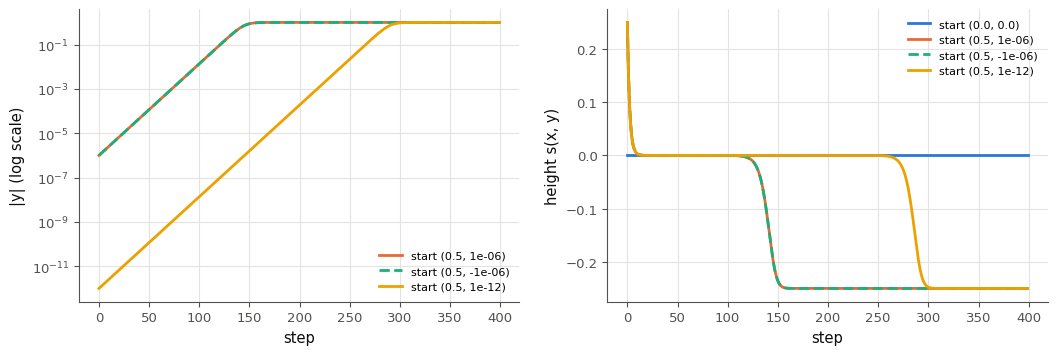

your predictions: a) True   b) 1   c) 100


In [38]:
if any(answer is ... or answer is None for answer in [prediction_5_20a, prediction_5_20b, prediction_5_20c]):
    print("⏳ Ex 5.20 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    fig, (ax_y, ax_s) = plt.subplots(1, 2, figsize=(12.5, 3.8))
    for colour, start in enumerate([(0.0, 0.0), (0.5, 1e-6), (0.5, -1e-6), (0.5, 1e-12)]):
        path = descend_20(start)
        beyond = np.flatnonzero(np.abs(path[:, 1]) > 0.5)
        first = int(beyond[0]) if beyond.size else None
        print(f"start {start}: after 2,000 steps ({path[-1, 0]:.3f}, {path[-1, 1]:.3f}); first step with |y| > 0.5: {first}")
        height = path[:, 0] ** 2 + path[:, 1] ** 4 / 4 - path[:, 1] ** 2 / 2
        ax_s.plot(height[:400], color=f"C{colour}", ls="--" if start[1] < 0 else "-", label=f"start {start}")
        if start[1] != 0:                                    # |y| = 0 has no logarithm
            ax_y.semilogy(np.abs(path[:400, 1]), color=f"C{colour}", ls="--" if start[1] < 0 else "-",
                          label=f"start {start}")
    ax_y.set(xlabel="step", ylabel="|y| (log scale)")
    ax_s.set(xlabel="step", ylabel="height s(x, y)")
    ax_y.legend(fontsize=8)
    ax_s.legend(fontsize=8)
    plt.show()
    print(f"your predictions: a) {prediction_5_20a}   b) {prediction_5_20b}   c) {prediction_5_20c}")

Près du point selle, $|y|$ est petit et $y^3$ est négligeable devant $y$ : un pas fait alors $y \leftarrow y - \eta\,(y^3 - y) \approx (1 + \eta)\,y = 1{,}1\,y$.

d) `extra_steps_5_20d` : avec ce facteur, combien de pas de plus faut-il pour que $|y|$ dépasse 0,5 quand le départ est $10^{-12}$ au lieu de $10^{-6}$, un million de fois plus près de l'axe ? (un entier, arrondi au plus proche ; compare-le ensuite à l'expérience)

In [39]:
extra_steps_5_20d = round(np.log(1e6) / np.log(1.1))     # 1.1 ** n = 10**6
print(extra_steps_5_20d, np.log(1e6) / np.log(1.1))

145 144.9531475685807


In [40]:
wb.record("5.20d", extra_steps_5_20d, mistakes={"tu as remplacé ln(1,1) par 0,1 : sa valeur est 0,0953, garde-la": round(np.log(1e6) / 0.1),
                                                 "c'est le nombre TOTAL de pas depuis 10⁻¹² : on demande les pas EN PLUS": 284,
                                                 "c'est le nombre de pas depuis 10⁻⁶ : on demande les pas EN PLUS quand on part de 10⁻¹²": 139,
                                                 "ln(10⁶) / ln(1,1) vaut environ 144,95 : arrondis au plus proche, pas vers le bas": 144})

WB_ANSWER {"hash": "2a614cd6d56c31245d97642ae70aeeff9b4ca8854a445df0af712a0109c1ddac", "id": "5.20d", "kind": "int", "magnitude": 2, "mistakes": {"82aa75dbc55bb745bbb9f43869205fe8297a460414ccf026c9e9b1caeb8ddd99": "ln(10⁶) / ln(1,1) vaut environ 144,95 : arrondis au plus proche, pas vers le bas", "c62e41cbf152a6f9f2b4f3cca89c768f516f16cd4e0ecf2dba0be5487f4e1cd0": "c'est le nombre TOTAL de pas depuis 10⁻¹² : on demande les pas EN PLUS", "f773ada4a31e9cb11c14f2a19810d358ef0c1e3acac6df2b2b58b3e02297b9fc": "c'est le nombre de pas depuis 10⁻⁶ : on demande les pas EN PLUS quand on part de 10⁻¹²", "ff03891b027093e3e1ac4dfabdc1590c9bfc0534e1b123ad346085f3ea12f37b": "tu as remplacé ln(1,1) par 0,1 : sa valeur est 0,0953, garde-la"}, "sign": 1}
📝 Ex 5.20d : réponse enregistrée (int).


💡 En $(0, 0)$, le gradient est exactement nul : la descente ne bouge pas, alors que ce n'est pas un minimum. Un millionième suffit pour en sortir, mais lentement : $y$ grandit de 10 % par pas, il faut 139 pas pour atteindre 0,5, puis la descente file vers le minimum $(0, 1)$, du côté où elle était. Pendant ces pas, la hauteur $s$ reste presque constante : un **plateau**, qui ressemble à une convergence. Partir un million de fois plus près de l'axe coûte 145 pas de plus ($\ln 10^6 / \ln 1{,}1$) : le temps passé près d'un point selle croît comme le logarithme de la distance initiale, ce qui reste lent en grande dimension (Du et coll., 2017, 🕰️ de la fiche). Le bruit de la descente stochastique (ch. 19) suffit à quitter la position exacte du point selle.

### Ex 5.21 — Le même gradient avec torch.autograd 📦 ★★ ⏱️ 20 min
**Objectif :** calculer un gradient par différentiation automatique avec PyTorch, le comparer au gradient numérique, et voir ce qu'il donne en un coin.  
**Prérequis :** Ex 5.15 · fiche, au-delà du livre (3) (🧮 PyTorch en cinq lignes) · quiz Q9 · **Fil rouge :** Rosenbrock · **Parcours :** R, C

La fonction `torch_gradient` ci-dessous calcule un gradient par **différentiation automatique** : PyTorch enregistre les opérations faites avec le tenseur `point`, puis `backward()` applique la règle de la chaîne en remontant ces opérations (fiche, au-delà du livre (3)). Il faut lui donner une fonction écrite avec des opérations que PyTorch sait dériver : `+`, `-`, `*`, `/`, `**`, `torch.exp`… mais pas les fonctions de NumPy.

Écris `rosenbrock_torch(p)` : la fonction de Rosenbrock ($a = 1$, $b = 100$) d'un tenseur `p` de deux composantes, `p[0]` et `p[1]`, avec ces opérations. La cellule de vérification l'appelle :
a) le gradient par autograd au point $(-0{,}8 ;\ 0{,}9)$ ; elle le compare ensuite à ton `numerical_gradient`.

La fonction $\max(0, x)$ (la ReLU des réseaux de neurones, ch. 17) a un point anguleux en 0 (quiz Q9) : sa pente vaut 0 à gauche et 1 à droite. PyTorch permet de l'écrire de plusieurs façons. Avec `torch_gradient` et ta fonction `numerical_derivative`, calcule quatre « pentes en 0 » :
b) `corner_21` : la liste [pente de `torch.relu(x)` en 0, pente de `torch.clamp(x, min=0)` en 0, pente de `torch.maximum(x, torch.zeros_like(x))` en 0, différence centrée de `max(0, x)` en 0].

La dernière cellule compare enfin les durées des deux méthodes sur une fonction de 2 000 variables. Dans tes notes : combien d'évaluations de la fonction coûte un gradient numérique pour $n$ variables ? Que penser de la « pente en 0 » de la ReLU ?

In [41]:
def torch_gradient(f, x):
    """Gradient of f at x by automatic differentiation, in float64 (to compare with a numerical gradient)."""
    if torch is None:
        raise NotImplementedError("PyTorch absent sur cet ordinateur : fais 5.21 sur Colab")
    point = torch.tensor(x, dtype=torch.float64, requires_grad=True)   # PyTorch records what is done with point
    f(point).backward()                                                # chain rule, from f(point) back to point
    return point.grad.numpy()                                          # df/dpoint, as a NumPy array


POINT_21 = [-0.8, 0.9]

In [42]:
def rosenbrock_torch(p):
    """Rosenbrock function (a = 1, b = 100) of a tensor p = [x, y], with operations that PyTorch can differentiate."""
    return (1 - p[0]) ** 2 + 100 * (p[1] - p[0] ** 2) ** 2


auto_21 = torch_gradient(rosenbrock_torch, POINT_21)
numeric_21 = mylearn.calculus.numerical_gradient(rosenbrock, POINT_21)
print(auto_21, numeric_21, f"largest gap {np.max(np.abs(auto_21 - numeric_21)):.1e}")
corner_21 = [float(torch_gradient(lambda p: torch.relu(p[0]), [0.0])[0]),
             float(torch_gradient(lambda p: torch.clamp(p[0], min=0), [0.0])[0]),
             float(torch_gradient(lambda p: torch.maximum(p[0], torch.zeros_like(p[0])), [0.0])[0]),
             mylearn.calculus.numerical_derivative(lambda x: max(0.0, x), 0.0)]
print(corner_21)

[79.6 52. ] [79.59999997 52.        ] largest gap 3.2e-08
[0.0, 1.0, 0.5, 0.5]


In [43]:
wb.record("5.21a", auto_21, decimals=4, mistakes={"le terme de la vallée est multiplié par b = 100 : (1 − x)² + 100 (y − x²)²": torch_gradient(lambda p: (1 - p[0]) ** 2 + (p[1] - p[0] ** 2) ** 2, POINT_21)})
wb.record("5.21b", corner_21, decimals=1, mistakes={"les trois écritures PyTorch ne donnent pas la même pente en 0 : calcule-les vraiment, l'une après l'autre": [0.0, 0.0, 0.0, 0.5],
                                                    "torch.clamp et torch.maximum ne donnent pas la même pente que torch.relu en 0 : calcule-les vraiment": [1.0, 1.0, 1.0, 0.5],
                                                    "c'est la différence AVANT : la différence centrée de max(0, x) en 0 vaut (h − 0) / (2h)": [0.0, 1.0, 0.5, 1.0],
                                                    "c'est la différence ARRIÈRE : la différence centrée de max(0, x) en 0 vaut (h − 0) / (2h)": [0.0, 1.0, 0.5, 0.0]})

WB_ANSWER {"decimals": 4, "element_coarse": [["c9dcfe3059cf5c45edd5e12b01ae3e3d257feddfaddaae04e2192f29e32d4300"], ["7a861b06be5ad7fc2a90399b6b14586dece0e7f678743ddd74fbbb2d923247de"]], "element_hashes": ["b6232acfd32343c2c9976006ce536c85587bff89441d3dd4131309f34d440035", "c5380ba15bc7d95d180ff521dfe71ffdbf7ddb71f63a778035d296e656000679"], "hash": "34c8134d6ad7748677180f6da67c0c20f7c1375b2d6af8e5a8bf4ab80bfe534d", "id": "5.21a", "kind": "array", "mistakes": {"e16ce454c5a43e07903827cc644d59c5a1419ff30ff818c9d32d9a68c7bc8cac": "le terme de la vallée est multiplié par b = 100 : (1 − x)² + 100 (y − x²)²"}, "shape": [2]}
📝 Ex 5.21a : réponse enregistrée (array, 4 décimale(s)).
WB_ANSWER {"decimals": 1, "element_hashes": ["0db5b267a981116075f171e43dd6bab492be634f4781b27fb3c1436c1c32109e", "10de51a6a0020f00e46a7c1b4281a01fe39887149ed587eacaf5ca0b339580b9", "b51ff7e48bb30bbfc1291d5e185a7315360d6326d79153c02ee1c95323478e4c", "9377076d00f5959b1348aea143aa882ed52ce1e578cb645d20310f4a1e112323"], "

**Le prix d'un gradient** : la même comparaison sur la fonction de Rosenbrock à 2 000 variables (`valley_21`), dont le code marche aussi bien sur un tableau NumPy que sur un tenseur. Exécute la cellule et compare les deux durées.

In [44]:
weights_21 = np.linspace(-1.0, 1.0, 2000)          # 2,000 variables


def valley_21(w):
    """Rosenbrock in 2,000 dimensions; the same code works on NumPy arrays and on PyTorch tensors."""
    return (100 * (w[1:] - w[:-1] ** 2) ** 2 + (1 - w[:-1]) ** 2).sum()


with wb.attempt("5.21"):
    mylearn.calculus.numerical_gradient(valley_21, weights_21[:3])      # first, make sure your function is written
    with wb.timer("numerical gradient, 2,000 variables"):
        numeric_big_21 = mylearn.calculus.numerical_gradient(valley_21, weights_21)
    with wb.timer("torch.autograd, 2,000 variables"):
        auto_big_21 = torch_gradient(valley_21, weights_21)
    print(f"largest gap between the two gradients: {np.max(np.abs(numeric_big_21 - auto_big_21)):.1e}")

⏱️ numerical gradient, 2,000 variables : 0.05 s
⏱️ torch.autograd, 2,000 variables : 0.00 s
largest gap between the two gradients: 9.4e-07


💡 Au point $(-0{,}8 ;\ 0{,}9)$, autograd donne $(79{,}6 ;\ 52)$, et la différence centrée le retrouve à environ $10^{-8}$ près (son erreur de troncature et d'arrondi). Autograd n'a pas de pas $h$ : son gradient est exact aux arrondis près. En 0, la ReLU n'a pas de dérivée : chaque opération de PyTorch a sa convention, alors que les trois écritures calculent la même fonction : 0 pour `torch.relu`, 1 pour `torch.clamp(x, min=0)`, 0,5 pour `torch.maximum`, qui partage la pente entre ses deux branches ; la différence centrée donne la moyenne des deux pentes, 0,5. En théorie, une entrée réelle ne tombe presque jamais pile sur 0 et le choix ne compte pas ; en `float32`, il modifie pourtant souvent les gradients calculés (quiz Q9 et fiche, 🕰️ ReLU). Enfin, le gradient numérique de 2 000 variables demande 4 000 évaluations de la fonction, contre une évaluation et un passage en arrière pour autograd : sur un réseau d'un million de paramètres, l'écart devient énorme (🧮 5.9).

## Partie D · Dessiner, tester, classer, et un défi

Fiche §5.4 et les pièges classiques. Tu dessines la goutte d'eau du livre sur la vallée de Rosenbrock, tu protèges un gradient numérique par des tests de propriétés, tu classes des points critiques, puis tu règles une descente pour atteindre le fond de la vallée.

### Ex 5.22 — L'eau qui descend la surface (figure 5.18) 🎨 ★★ ⏱️ 30 min
**Objectif :** dessiner une descente de gradient sur une surface en trois dimensions et sur sa carte, avec les directions de plus grande descente.  
**Prérequis :** Ex 5.18 · fiche §5.4 (descendre une surface pas à pas, 🧮 lignes de niveau et flèches) · livre figure 5.18 · **Fil rouge :** Rosenbrock · **Parcours :** C

Le livre montre la descente comme une goutte d'eau qui suit, pas après pas, la direction de plus grande descente (figures 5.16 et 5.18). Refais cette image sur la vallée de Rosenbrock : 3 000 pas de descente depuis $(-1{,}2 ;\ 1)$, le départ classique, avec `lr=0.001` et le gradient exact `rosenbrock_gradient`.

1. Écris `draw_surface_22(ax, path)` : sur l'axe 3D `ax`, la surface sur $[-2, 2] \times [-1, 3]$ (`np.meshgrid`, puis `ax.plot_surface(X, Y, Z, cmap=..., alpha=0.6)`), et par-dessus le chemin, à la hauteur de la surface (`ax.plot(xs, ys, zs)`), départ et arrivée marqués. En hauteur, prends $\log_{10}(1 + f)$ : les parois montent jusqu'à 2 500 et écraseraient la vallée (le logarithme garde les mêmes directions de descente).
2. Écris `draw_map_22(ax, path)` : sur un axe ordinaire, la carte de la même surface (`wb.plot.plot_contour(wb.synth.rosenbrock, ..., ax=ax)` trace les lignes de niveau et le chemin), et, tous les 300 pas, une flèche dans la direction de plus grande descente $-\nabla f$ (`ax.quiver` ; divise chaque flèche par sa norme pour qu'elles aient toutes la même longueur).

La vérification calcule le chemin avec ta fonction `gradient_descent`, contrôle sa forme, puis trace les deux panneaux avec tes fonctions. Compare avec la figure du corrigé, puis réponds dans tes notes : où en est la goutte après 3 000 pas ? Pourquoi descend-elle si vite au début, et si lentement ensuite ?

In [45]:
START_22 = [-1.2, 1.0]
LR_22, STEPS_22 = 0.001, 3000

after 3,000 steps: [0.84247074 0.70906503] f = 0.024863343078694304 · after 1 step: f = 5.352911580008964


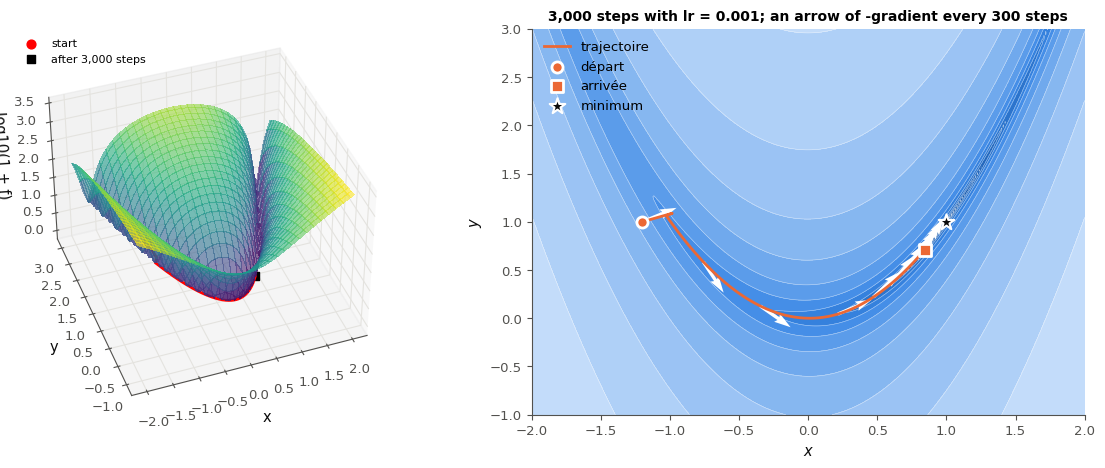

In [46]:
def draw_surface_22(ax, path):
    """The surface log10(1 + f) on [-2, 2] x [-1, 3] (3-D axis ax), with the path drawn on it."""
    X, Y = np.meshgrid(np.linspace(-2, 2, 60), np.linspace(-1, 3, 60))
    ax.plot_surface(X, Y, np.log10(1 + wb.synth.rosenbrock(X, Y)), cmap="viridis", alpha=0.6, linewidth=0,
                    antialiased=False)
    path = np.asarray(path)
    heights = np.log10(1 + wb.synth.rosenbrock(path[:, 0], path[:, 1]))
    ax.plot(path[:, 0], path[:, 1], heights, color="red", lw=2)
    ax.scatter(path[0, 0], path[0, 1], heights[0], color="red", s=40, label="start")
    ax.scatter(path[-1, 0], path[-1, 1], heights[-1], color="black", marker="s", s=40, label="after 3,000 steps")
    ax.view_init(elev=40, azim=-110)
    ax.set(xlabel="x", ylabel="y", zlabel="log10(1 + f)")
    ax.legend(loc="upper left", fontsize=8)


def draw_map_22(ax, path):
    """The map of the same surface, the path, and a unit arrow of -gradient every 300 steps."""
    path = np.asarray(path)
    wb.plot.plot_contour(wb.synth.rosenbrock, xlim=(-2, 2), ylim=(-1, 3), path=path, ax=ax, minimum=(1, 1), levels=15)
    marks = path[::300]
    arrows = -np.array([rosenbrock_gradient(point) for point in marks])
    arrows = arrows / np.linalg.norm(arrows, axis=1, keepdims=True)
    ax.quiver(marks[:, 0], marks[:, 1], arrows[:, 0], arrows[:, 1], color="white", scale=15, width=0.006)
    ax.set_title("3,000 steps with lr = 0.001; an arrow of -gradient every 300 steps", fontsize=10)


end_22, path_22 = mylearn.calculus.gradient_descent(rosenbrock_gradient, START_22, lr=LR_22, n_steps=STEPS_22)
print("after 3,000 steps:", end_22, "f =", rosenbrock(end_22), "· after 1 step: f =", rosenbrock(path_22[1]))
fig = plt.figure(figsize=(12, 4.8))
try:
    draw_surface_22(fig.add_subplot(1, 2, 1, projection="3d"), path_22)
    draw_map_22(fig.add_subplot(1, 2, 2), path_22)
except BaseException:
    plt.close(fig)                    # no empty figure while the drawing functions are not written
    raise
plt.tight_layout()
plt.show()

💡 Le premier pas fait tomber $f$ de 24,2 à 5,4 : la goutte part de la paroi, où la pente est très forte, et tombe presque d'un coup au fond de la vallée. Ensuite, elle suit le fond en courbe, où la pente est faible : après 3 000 pas, elle n'est qu'en $(0{,}84 ;\ 0{,}71)$, avec $f \approx 0{,}025$, encore loin de $(1, 1)$. Les flèches de $-\nabla f$ pointent presque perpendiculairement au fond de la vallée, vers lui, et non vers le minimum : la goutte est sans cesse ramenée au fond, et n'avance que par la petite composante qui le longe (fiche, ⚠️ les limites de l'image de l'eau).

### Ex 5.23 — Tests de propriétés paramétrés avec pytest 🛠️ ★★ ⏱️ 20 min
**Objectif :** tester une fonction numérique par des propriétés vraies sur beaucoup d'entrées, avec `@pytest.mark.parametrize`.  
**Prérequis :** Ex 5.15 · 0A.62 (pytest, parametrize) · Ex 4.23 · **Parcours :** C

Pour une fonction numérique, on ne connaît pas toujours la valeur exacte attendue ; on connaît en revanche des **propriétés** qu'elle doit respecter sur beaucoup d'entrées. C'est l'idée des **tests de propriétés** : un même test, répété sur plusieurs entrées avec `@pytest.mark.parametrize` (0A.62). Pour un gradient numérique, par exemple :
- sur une forme quadratique $f(\mathbf{x}) = \mathbf{x}^\top A\,\mathbf{x} + \mathbf{b}^\top\mathbf{x}$, le gradient exact est $(A + A^\top)\,\mathbf{x} + \mathbf{b}$ (0B), et la différence centrée le retrouve aux arrondis près ; on peut le vérifier en dimension 1, 2, 5…, avec des $A$, $\mathbf{b}$ et $\mathbf{x}$ tirés au hasard avec une graine ;
- un point écrit en entiers donne le même gradient que le même point écrit en flottants ;
- le gradient a la forme du point, même quand le point est une matrice.

Écris au moins **trois** tests pytest qui appellent `numerical_gradient(f, x)`, dont **au moins un** paramétré par `@pytest.mark.parametrize`, et range-les dans la liste `my_tests_23`. Comme en 4.23, la vérification lance vraiment pytest : tes tests doivent **passer** sur une version juste (`gradient_ok_23`) et **échouer** sur chacune des trois versions buggées de la cellule ci-dessous (lis-les). Pour comparer des flottants, prends une tolérance serrée, `np.allclose(..., atol=1e-6)` par exemple : une tolérance trop large laisserait passer un bug. Tes tests peuvent utiliser `numerical_gradient`, `np`, `math` et `pytest` ; seules tes fonctions de test sont copiées dans le fichier que lance pytest : définis tout ce dont elles ont besoin (une fonction $f$, une matrice) **à l'intérieur** de chaque test.

In [47]:
def gradient_ok_23(f, x, h=1e-5):
    """A correct numerical gradient, to test your tests."""
    point = np.array(x, dtype=float)
    flat, grad = point.reshape(-1), np.zeros_like(point)
    flat_grad = grad.reshape(-1)
    for i in range(flat.size):
        old = flat[i]
        flat[i] = old + h
        f_plus = f(point)
        flat[i] = old - h
        f_minus = f(point)
        flat[i] = old
        flat_grad[i] = (f_plus - f_minus) / (2 * h)
    return grad


def gradient_bug_1_23(f, x, h=1e-5):
    """Bug 1: the forward difference instead of the central one."""
    point = np.array(x, dtype=float)
    flat, grad = point.reshape(-1), np.zeros_like(point)
    flat_grad = grad.reshape(-1)
    f_here = f(point)
    for i in range(flat.size):
        old = flat[i]
        flat[i] = old + h
        flat_grad[i] = (f(point) - f_here) / h
        flat[i] = old
    return grad


def gradient_bug_2_23(f, x, h=1e-5):
    """Bug 2: copies x but keeps its type, so an integer point stays an integer array."""
    point = np.array(x)
    flat, grad = point.reshape(-1), np.zeros(point.shape)
    flat_grad = grad.reshape(-1)
    for i in range(flat.size):
        old = flat[i]
        flat[i] = old + h
        f_plus = f(point)
        flat[i] = old - h
        f_minus = f(point)
        flat[i] = old
        flat_grad[i] = (f_plus - f_minus) / (2 * h)
    return grad


def gradient_bug_3_23(f, x, h=1e-5):
    """Bug 3: only right for a vector; for a matrix, point[i] is a whole row."""
    point = np.array(x, dtype=float)
    grad = np.zeros(len(point))
    for i in range(len(point)):
        old = point[i].copy()
        point[i] = old + h
        f_plus = f(point)
        point[i] = old - h
        f_minus = f(point)
        point[i] = old
        grad[i] = (f_plus - f_minus) / (2 * h)
    return grad

In [48]:
@pytest.mark.parametrize("n, seed", [(1, 0), (2, 1), (5, 2)])
def test_matches_the_gradient_of_a_quadratic_form(n, seed):
    rng = np.random.default_rng(seed)
    A, b, x = rng.normal(size=(n, n)), rng.normal(size=n), rng.normal(size=n)
    result = numerical_gradient(lambda v: v @ A @ v + b @ v, x)
    assert np.allclose(result, (A + A.T) @ x + b, atol=1e-6)


def test_an_integer_point_gives_the_same_gradient():
    def f(v):
        return v[0] ** 2 * v[1] + 3 * v[1]
    assert np.allclose(numerical_gradient(f, np.array([-1, 2])), numerical_gradient(f, np.array([-1.0, 2.0])),
                       atol=1e-6)


def test_the_gradient_of_a_matrix_has_its_shape():
    W = np.arange(6.0).reshape(2, 3)
    result = numerical_gradient(lambda M: np.sum(M ** 2), W)
    assert result.shape == (2, 3)
    assert np.allclose(result, 2 * W, atol=1e-6)


my_tests_23 = [test_matches_the_gradient_of_a_quadratic_form, test_an_integer_point_gives_the_same_gradient,
               test_the_gradient_of_a_matrix_has_its_shape]
if not filled(my_tests_23):
    print("⏳ Ex 5.23 : tests pas encore écrits.")
else:
    marked_23 = [test for test in my_tests_23
                 if any(mark.name == "parametrize" for mark in getattr(test, "pytestmark", []))]
    verdict("5.23", len(my_tests_23) >= 3 and len(marked_23) >= 1,
            f"{len(my_tests_23)} tests, dont {len(marked_23)} paramétré(s) par @pytest.mark.parametrize.",
            "il faut au moins trois tests, dont au moins un décoré par @pytest.mark.parametrize.")
    good_23 = wb.run_pytest(my_tests_23, subject=gradient_ok_23, name="numerical_gradient")
    verdict("5.23", good_23.ok, f"tes tests passent sur une version juste ({good_23.passed} cas).",
            "tes tests doivent tous passer sur une version juste (voir le détail au-dessus).")
    if good_23.ok:
        for bug in [gradient_bug_1_23, gradient_bug_2_23, gradient_bug_3_23]:
            result = wb.run_pytest(my_tests_23, subject=bug, name="numerical_gradient", quiet=True)
            verdict("5.23", result.failed + result.errors > 0, f"{bug.__name__} est attrapé ({result.failed} cas en échec).",
                    f"tes tests passent sur {bug.__name__}, qui est faux : ajoute un test qui le fait échouer.")

✅ Ex 5.23 : 3 tests, dont 1 paramétré(s) par @pytest.mark.parametrize.


pytest : 5 passed in 0.07s
✅ Ex 5.23 : tes tests passent sur une version juste (5 cas).


✅ Ex 5.23 : gradient_bug_1_23 est attrapé (2 cas en échec).


✅ Ex 5.23 : gradient_bug_2_23 est attrapé (1 cas en échec).


✅ Ex 5.23 : gradient_bug_3_23 est attrapé (1 cas en échec).


💡 Chaque propriété attrape un bug. La forme quadratique, avec une tolérance de $10^{-6}$, attrape la différence avant (bug 1) : son erreur, environ $h\,A_{ii}$, vaut quelques $10^{-5}$, alors que la différence centrée est exacte sur un polynôme de degré 2, aux arrondis près (∂ 5.6). Le point entier attrape le bug 2 (les décalages de $h$ sont tronqués), à condition de choisir un point où la vraie dérivée n'est pas nulle : en $(0, 0)$, les décalages tronqués donnent un gradient nul qui peut être juste par hasard. La matrice attrape le bug 3. Un seul cas « calculé à la main » n'en aurait attrapé qu'un ; les propriétés vérifiées sur plusieurs entrées tirées au hasard (avec une graine, pour que l'échec soit reproductible) couvrent bien plus de situations. La bibliothèque *Hypothesis* pousse l'idée plus loin : elle choisit elle-même les entrées, et réduit un échec au plus petit exemple qui le provoque.

### Ex 5.24 — Minimum, maximum, selle ou plat : classify_critical_point 🔨 ★★★ ⏱️ 35 min
**Objectif :** classer un point critique par les signes des dérivées secondes dans plusieurs directions, sans matrice hessienne.  
**Prérequis :** Ex 5.11, Ex 5.15 · ✏️ 5.5 · fiche §5.4 (les points où le gradient s'annule) · **Fil rouge :** synthétique · **mylearn :** `calculus.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/calculus.py`, mêmes règles qu'en 5.11 (NumPy permis, SciPy et PyTorch non). Enregistre, puis relance la cellule de vérification.

Écris `classify_critical_point(f, x, h=1e-3, tol=1e-6, grad_tol=1e-4)` (lis sa docstring) :
- `x` doit être à une dimension, sinon `ValueError` ; si la norme de `numerical_gradient(f, x)` (ta fonction de 5.15, avec son pas par défaut) dépasse `grad_tol`, `x` n'est pas un point critique : `ValueError` ;
- les directions $\mathbf{d}$ : les axes $\mathbf{e}_i$, puis les diagonales $\mathbf{e}_i + \mathbf{e}_j$ et $\mathbf{e}_i - \mathbf{e}_j$ pour $i < j$ (`np.eye(n)` donne les $\mathbf{e}_i$) ;
- dans chaque direction, la différence seconde $D_\mathbf{d} = \frac{f(\mathbf{x} + h\mathbf{d}) - 2f(\mathbf{x}) + f(\mathbf{x} - h\mathbf{d})}{h^2}$ ; une valeur telle que $|D_\mathbf{d}| \le$ `tol` compte comme nulle ;
- renvoie `"minimum"` si toutes les $D_\mathbf{d}$ sont $>$ `tol`, `"maximum"` si toutes sont $<$ `-tol`, `"saddle"` s'il y en a des deux signes, et `"flat"` sinon (on ne peut pas conclure).

Vérifications sur $h(\mathbf{v}) = v_0^4 + v_1^4 - 4\,v_0 v_1$ (`h_24`, dont les points critiques sont $(0, 0)$, $(1, 1)$ et $(-1, -1)$) et sur $k(\mathbf{v}) = v_0^3 + v_1^2$ (`k_24`). La cellule de vérification appelle ta fonction :
a) en $(0, 0)$, pour $h$ ;
b) en $(1, 1)$, pour $h$ ;
c) en $(0, 0)$, pour $k$ ;
d) le nom de l'erreur levée en $(1, 0)$, pour $h$ ;
puis les tests de `classify_critical_point`.

Dans tes notes : en $(0, 0)$, $h$ ne varie le long des axes qu'en $v^4$ : quelles directions décident du verdict ? Le résultat de c) dit-il que $(0, 0)$ est un minimum de $k$ ? Que vaut $k$ en $(-0{,}1 ;\ 0)$ ?

In [49]:
def h_24(v):
    """v0⁴ + v1⁴ - 4 v0 v1: critical points (0, 0), (1, 1) and (-1, -1)."""
    return v[0] ** 4 + v[1] ** 4 - 4 * v[0] * v[1]


def k_24(v):
    """v0³ + v1²."""
    return v[0] ** 3 + v[1] ** 2

In [50]:
kinds_24 = [mylearn.calculus.classify_critical_point(h_24, [0.0, 0.0]),
            mylearn.calculus.classify_critical_point(h_24, [1.0, 1.0]),
            mylearn.calculus.classify_critical_point(k_24, [0.0, 0.0])]
error_24 = error_name(mylearn.calculus.classify_critical_point, h_24, [1.0, 0.0])
hessian_24 = np.array([[12.0, -4.0], [-4.0, 12.0]])          # the second derivatives of h at (1, 1), by hand
print(kinds_24, error_24, "eigenvalues of the Hessian of h at (1, 1):", np.linalg.eigvalsh(hessian_24),
      "k(-0.1, 0) =", k_24([-0.1, 0.0]))
run_calculus_tests("test_classify_critical_point_", impl="ref")

['saddle', 'minimum', 'flat'] ValueError eigenvalues of the Hessian of h at (1, 1): [ 8. 16.] k(-0.1, 0) = -0.0010000000000000002


pytest: 21 passed, 85 deselected in 1.72s


In [51]:
wb.record("5.24a", kinds_24[0], mistakes={"tu n'as regardé que les axes, où h ne varie qu'en v⁴ : le long des diagonales, h descend dans un sens (v0 = v1) et monte dans l'autre": "minimum",
                                          "le long des axes, h est presque plate ; regarde aussi les diagonales, où elle descend dans un sens et monte dans l'autre": "flat"})
wb.record("5.24b", kinds_24[1], mistakes={"en (1, 1), h monte dans toutes les directions : vérifie le signe de tes différences secondes": "saddle"})
wb.record("5.24c", kinds_24[2], mistakes={"le long de l'axe v0, k vaut v³ : la différence seconde y est nulle, on ne peut pas conclure (et ce n'est pas un minimum : k(−0,1 ; 0) < 0)": "minimum"})
wb.record("5.24d", error_24, mistakes={"(1, 0) n'est pas un point critique (le gradient y vaut (4, −4)) : la fonction doit le refuser par une ValueError": "no error"})

WB_ANSWER {"hash": "2c27466485331298ec0f66d198e3dfd4c8a8054b25e199c1e09c5f547b068481", "id": "5.24a", "kind": "str", "mistakes": {"9dc26f20eecdb59ac8f2bf76010cb13735312062071afbefc907178e71f26ae0": "tu n'as regardé que les axes, où h ne varie qu'en v⁴ : le long des diagonales, h descend dans un sens (v0 = v1) et monte dans l'autre", "f75bfb9bba790209654b49a10f753dac92293d6c3c42fbecfcf101c6140a4996": "le long des axes, h est presque plate ; regarde aussi les diagonales, où elle descend dans un sens et monte dans l'autre"}}
📝 Ex 5.24a : réponse enregistrée (str).
WB_ANSWER {"hash": "40fb4cc5c1254adbb17b1944a1db8d08b8ebdc4c82040f2b7d46380b19a2895f", "id": "5.24b", "kind": "str", "mistakes": {"dac14386f2a047d340533a9c37b40bc5c45f9cf3033f1c442a7074296e3ae617": "en (1, 1), h monte dans toutes les directions : vérifie le signe de tes différences secondes"}}
📝 Ex 5.24b : réponse enregistrée (str).
WB_ANSWER {"hash": "58db787811e9c534b453aab783b72c82d033c3e1897eaf95f8319547f5be7f6f", "id": "5.2

💡 En $(0, 0)$, $h$ vaut $v^4$ le long de chaque axe : la différence seconde y est minuscule ($2 \times (10^{-3})^2 = 2 \times 10^{-6}$ avec le pas par défaut `h=1e-3`, juste au-dessus de `tol`). Ce sont les diagonales qui tranchent : le long de $v_0 = v_1$, $h \approx -4t^2$ descend ; le long de $v_0 = -v_1$, $h \approx 4t^2$ monte : c'est une selle. En $(1, 1)$, la matrice des dérivées secondes $\begin{pmatrix} 12 & -4 \\ -4 & 12 \end{pmatrix}$ a deux valeurs propres positives (8 et 16) : un minimum. En $(0, 0)$, $k$ monte dans la direction $v_1$, mais vaut $v_0^3$ le long de l'axe $v_0$ : la différence seconde y est nulle, et la fonction répond « plat », c'est-à-dire « je ne peux pas conclure ». À raison : $k(-0{,}1 ;\ 0) = -0{,}001 < 0 = k(0, 0)$, ce n'est pas un minimum. Comme pour $x^3$ en 0 (piège classique de la fiche), une dérivée seconde nulle ne permet pas de conclure. Regarder les axes et les diagonales ne suffit pas toujours : une forme quadratique peut monter le long de toutes ces directions et descendre entre elles (voir `05_solutions.md`) ; la matrice hessienne (ch. 19) règle le cas général.

### Ex 5.25 — Atteindre le fond de la vallée de Rosenbrock 🏆 ★★★ ⏱️ 60 min
**Objectif :** régler un learning rate, ou un petit programme de learning rates, pour atteindre et tenir le minimum d'une vallée mal conditionnée.  
**Prérequis :** Ex 5.18, Ex 5.19 · ∂ 5.7 · fiche §5.4 (Rosenbrock) · **Fil rouge :** Rosenbrock · **Parcours :** C

**Défi.** Pars de $(-1{,}5 ;\ 2)$ et descends la vallée de Rosenbrock ($a = 1$, $b = 100$) jusqu'au minimum $(1, 1)$, avec ta fonction `gradient_descent` et le gradient exact `rosenbrock_gradient`. Écris `schedule_25()`, qui renvoie ton **programme** : une liste de 1 à 3 phases `(lr, n_steps)`, jouées l'une après l'autre, chaque phase repartant du point où la précédente s'est arrêtée. Règles :
- chaque phase compte au moins 100 pas, et le total au plus **10 000 pas** ;
- à la fin, le point est à moins de $10^{-3}$ de $(1, 1)$ (distance euclidienne) ;
- et il y **reste** : 10 000 pas de plus avec le learning rate de la dernière phase ne doivent jamais l'en éloigner de $10^{-3}$ ou plus, et doivent finir à moins de $10^{-4}$ de $(1, 1)$.

Commence par mesurer, avec un seul learning rate : combien de pas faut-il avec 0,001 ? avec 0,0015 ? avec 0,002 ? Pistes : la leçon du bol de 5.19 (le plus grand learning rate possible dépend de la courbure la plus forte) s'applique au fond de la vallée, où la courbure la plus forte vaut environ 1 000 (∂ 5.7) ; et la règle « il y reste » n'est pas là pour rien.

In [52]:
START_25 = (-1.5, 2.0)                   # a tuple: nothing can change it
TARGET_25 = np.array([1.0, 1.0])


def grade_25(phases, start=(-1.5, 2.0), target=(1.0, 1.0)):
    """Play the phases with YOUR gradient_descent from `start`: (total steps, final distance to `target`, then, during
    10,000 more steps with the last learning rate, the worst distance and the distance at the end)."""
    point, target = np.array(start, dtype=float), np.array(target, dtype=float)
    for lr, n_steps in phases:
        point, _ = mylearn.calculus.gradient_descent(rosenbrock_gradient, np.array(point, dtype=float), lr=lr,
                                                    n_steps=int(n_steps))
    final = float(np.linalg.norm(np.asarray(point, dtype=float) - target))
    _, stay = mylearn.calculus.gradient_descent(rosenbrock_gradient, np.array(point, dtype=float), lr=phases[-1][0],
                                                n_steps=10_000)
    distances = np.linalg.norm(np.asarray(stay, dtype=float) - target, axis=1)
    return sum(int(n_steps) for _, n_steps in phases), final, float(distances.max()), float(distances[-1])

In [53]:
def steps_to_reach_25(lr, max_steps=20_000):
    """Number of steps of YOUR gradient_descent from START_25 until the distance to (1, 1) is < 1e-3 (None if never)."""
    with np.errstate(over="ignore", invalid="ignore"):
        _, path = mylearn.calculus.gradient_descent(rosenbrock_gradient, START_25, lr=lr, n_steps=max_steps)
        close = np.flatnonzero(np.linalg.norm(path - TARGET_25, axis=1) < 1e-3)
    return int(close[0]) if close.size else None


for lr in (0.001, 0.0015, 0.0018, 0.0019, 0.00194, 0.00195, 0.002, 0.0021):
    print(f"lr = {lr}: {steps_to_reach_25(lr)} steps")
print("lr = 0.002 reaches (1, 1), but does it stay? (steps, final distance, worst and last distances afterwards):",
      grade_25([(0.002, 6000)]))
print("eigenvalues of the Hessian at (1, 1):", np.linalg.eigvalsh([[802.0, -400.0], [-400.0, 200.0]]))


def schedule_25():
    """Your programme: a list of 1 to 3 phases (lr, n_steps), played one after the other from START_25."""
    return [(0.0019, 8500)]


print("two phases, (0.002, 5000) then (0.0019, 1000):", grade_25([(0.002, 5000), (0.0019, 1000)]))
with wb.attempt("5.25"):
    schedule_value_25 = schedule_25()
    phases_25 = ([tuple(phase) for phase in schedule_value_25]                # a list of (lr, n_steps) pairs
                 if isinstance(schedule_value_25, (list, tuple))
                 and all(isinstance(phase, (list, tuple)) for phase in schedule_value_25) else [])
    if not (1 <= len(phases_25) <= 3 and all(len(phase) == 2 and all(np.ndim(v) == 0 and np.issubdtype(np.asarray(v).dtype, np.number)
                                                                     for v in phase)
                                                and phase[0] > 0 and float(phase[1]).is_integer() and phase[1] >= 100
                                                for phase in phases_25)):
        verdict("5.25", False, "", "schedule_25() doit renvoyer une liste de 1 à 3 phases (lr, n_steps) : lr un nombre "
                "> 0, n_steps un entier au moins égal à 100 ; une seule phase s'écrit aussi entre crochets, "
                f"[(0.001, 5000)]. J'ai reçu {schedule_value_25!r}.")
    else:
        with np.errstate(over="ignore", invalid="ignore"):
            total_25, final_25, worst_25, end_25 = grade_25(phases_25)
        print(f"{len(phases_25)} phase(s), {total_25} steps: final distance {final_25:.2e}; during the next 10,000 "
              f"steps: worst distance {worst_25:.2e}, distance at the end {end_25:.2e}")
        verdict("5.25", total_25 <= 10_000 and final_25 < 1e-3 and worst_25 < 1e-3 and end_25 < 1e-4,
                f"défi réussi : (1, 1) atteint à {final_25:.1e} près en {total_25} pas, et tenu.",
                "il faut au plus 10 000 pas et une distance finale inférieure à 1e-3 ; puis, pendant les 10 000 pas "
                "suivants, ne jamais s'éloigner à 1e-3 ou plus, et finir à moins de 1e-4.")

lr = 0.001: 17695 steps


lr = 0.0015: 11529 steps


lr = 0.0018: 9503 steps


lr = 0.0019: 8222 steps


lr = 0.00194: 3327 steps


...

lr = 0.002: 5387 steps


lr = 0.0021: None steps


lr = 0.002 reaches (1, 1), but does it stay? (steps, final distance, worst and last distances afterwards): (6000, 0.0006124542712406739, 0.004339467529366201, 0.002490101766821504)
eigenvalues of the Hessian at (1, 1): [3.99360767e-01 1.00160064e+03]


two phases, (0.002, 5000) then (0.0019, 1000): (6000, 0.0006374366359930195, 0.0006374366359930195, 3.2186561785024145e-07)


1 phase(s), 8500 steps: final distance 8.09e-04; during the next 10,000 steps: worst distance 8.09e-04, distance at the end 4.09e-07
✅ Ex 5.25 : défi réussi : (1, 1) atteint à 8.1e-04 près en 8500 pas, et tenu.


💡 Avec un seul learning rate : 0,001 demande environ 17 700 pas, 0,0015 environ 11 500 ; il faut monter vers 0,0018 (9 500 pas) ou 0,0019 (8 200 pas) pour tenir dans le budget. Près de la limite, le nombre de pas varie de façon irrégulière (3 300 pour 0,00194, 4 700 pour 0,00195, 5 400 pour 0,002) : partie de la paroi très raide, où le gradient vaut environ 160, la goutte fait d'abord quelques sauts énormes, et l'endroit où elle retombe dans la vallée change beaucoup avec $\eta$. Avec 0,00194, elle atterrit presque sur $(1, 1)$ en 6 pas ; avec 0,0019, vers $(0{,}4 ;\ 0{,}6)$, et il lui reste toute la vallée à parcourir. Avec 0,002, la goutte atteint $(1, 1)$, mais n'y reste pas : une oscillation en travers de la vallée grandit, jusqu'à $4 \times 10^{-3}$. Au fond de la vallée, la matrice des dérivées secondes $\begin{pmatrix} 802 & -400 \\ -400 & 200 \end{pmatrix}$ a pour valeurs propres environ 1 001,6 (en travers) et 0,4 (le long du fond) : comme sur le bol de 5.19, l'oscillation en travers ne s'amortit que si $\eta \times 1\,001{,}6 < 2$, soit $\eta < 0{,}001997$. Juste au-dessus, elle grandit si lentement que 10 000 pas ne le montrent pas ; à 0,002, elle se voit déjà. Le long du fond, chaque pas ne multiplie l'écart que par $1 - 0{,}4\,\eta \approx 0{,}9992$ : d'où les milliers de pas. Un programme en deux phases réussit aussi : (0,002 ; 5 000), puis (0,0019 ; 1 000), qui amortit l'oscillation. C'est l'idée des programmes de learning rate (*schedules*) et des optimiseurs adaptatifs du ch. 19 : la vallée de Rosenbrock y reviendra.

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu estimer une dérivée par différences finies, et expliquer comment choisir le pas $h$ ?
2. Sais-tu calculer un gradient, le lire sur une carte de lignes de niveau, et classer un point critique ?
3. Sais-tu écrire une descente de gradient, et reconnaître un learning rate trop petit ou trop grand ?

**Pour aller plus loin** : les références de la fiche (la vidéo de 3Blue1Brown sur la descente de gradient, l'article de *Distill* sur les vallées mal proportionnées, l'introduction à `torch.autograd`). La suite : le ch. 6 (information et entropie), puis le ch. 18, où `numerical_gradient` vérifiera tes rétropropagations, et le ch. 19, où la vallée de Rosenbrock et `gradient_descent` serviront à comparer les optimiseurs.